# 15 analysis — cross-model robustness and 2024–2026 year-family story

This notebook is the **validation plane** for a future multi-teacher middle layer, and the **year-move story** (what improved, what did not, what gaps closed).

Sandwich claim: freeze LoCoMo + `qa_mem0_v1` + gpt-4o-mini judge; vary only memory. Reader-model and teacher-model swaps are a **separate** robustness axis. If FC vs RAG ranking, or teacher_graph vs session-summary ranking, **flips** across 2025/2026 or OpenAI/DeepSeek, a pooled-teacher result cannot treat the other axis as interchangeable.

Family plots that include thinking split on vs off **within** OpenAI and DeepSeek (`hue=thinking`). Do not average on/off cells.

Year-over-year condition comparisons are `kind: line` with `x=generation` (one polyline per family × method × thinking; thinking-off is dashed). Bars stay for side-by-side scores. Insight CSVs (`year_deltas`, `rank_flips`, holes) are the labels; the lines are the same mean tables.

2024 paper / local_clone pins are **not** a matched sandwich vs 2025 live GPT-5. Use `pin_vs_live_2025` as a literature orientation only. The matched comparison is live 2025 → live 2026.

Cost, latency, and reasoning tokens are in the same report so **ROI** (score per second / per $1 / per 1k reasoning tokens) and **benchmark saturation** (`near_ceiling`, `diminishing_returns`) can be read next to F1/J.


In [2]:
from pathlib import Path
import sys

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.memorybench.analysis.load_campaign import load_campaign_yaml
from src.memorybench.analysis.notebook_protocol import notebook_posttest, notebook_pretest
from src.memorybench.analysis.report import render_campaign

YAML = ROOT / "configs" / "analysis" / "campaign_year_family.yaml"
camp = load_campaign_yaml(YAML)
print(camp.id, "->", YAML)
print("insights:", [spec.id for spec in camp.insights])


year_family -> C:\home\research\Distillation\distillation\configs\analysis\campaign_year_family.yaml
insights: ['reader_year_deltas', 'reader_family_gaps', 'reader_thinking_deltas', 'reader_method_ranks', 'reader_rank_flips', 'reader_fc_holes', 'reader_rag_holes', 'writer_year_deltas', 'writer_family_gaps', 'writer_thinking_deltas', 'writer_method_ranks', 'writer_rank_flips', 'writer_holes', 'pin_vs_live_2025', 'reader_latency_year_deltas', 'reader_token_year_deltas', 'writer_token_year_deltas', 'reader_efficiency', 'writer_efficiency', 'reader_roi_year_deltas', 'writer_roi_year_deltas', 'reader_saturation', 'writer_saturation']


## Pre-test

Declared cells and hypotheses. Missing 2026 packs are skipped later, not failed. `cost:` prices each live pack when `cost.json` exists (expected ≈ actual for finished cells; empty until 2026 QA finishes).


In [3]:
_ = notebook_pretest(camp, root=ROOT)


## Pre-test — Cross-model robustness and 2024–2026 year-family story

Judge score is Mem0 J (category 5 excluded). Paper rows are Table 2 literature pins (gpt-4o-class, 2024). local_clone is this repo's gpt-4o-mini architecture clone. live 2025/2026 readers are GPT-5 / GPT-5.6 Terra / DeepSeek answering over frozen full_context or rag with matched thinking on/off. live writers freeze gpt-4o-mini as the reader and vary the teacher × thinking. teacher_session_summaries / teacher_graph are not Mem0 extract/update. Do not average on/off cells. 2024→2025 pin vs live is a different stack (not a matched sandwich delta). 2025→2026 live matched cells are the robustness check for a future multi-teacher middle layer: if FC vs RAG ranking or family gaps flip, a pooled-teacher claim cannot treat the reader as interchangeable. Cost, latency, and reasoning tokens sit next to F1/J so ROI (score per second / per $ / per 1k reasoning tokens) and benchmark saturation (near_ceiling, diminishing_returns) are first-class. Prior GPT-5 writer packs that collapsed under high thinking + 1024 tokens are historical, not in this matrix.

Config: `C:/home/research/Distillation/distillation/configs/analysis/campaign_year_family.yaml`

### `readers` — `locomo-2025-readers-openai-deepseek`
- scientific claim: yes (still not Mem0 paper J)
- expected cells: **8**
- expected questions / cell: **1986**
- hypothesis: GPT-5 vs DeepSeek-V3 × {full_context, rag} × thinking on/off is the 2025 reader robustness plane.
- hypothesis: Do not average thinking on/off cells.
- hypothesis: Thinking-on cells cost more tokens and seconds; quality gain vs that spend is an ROI question, not assumed.

### `writers` — `locomo-mem0-reader-2025-writers-openai-deepseek`
- scientific claim: yes (still not Mem0 paper J)
- expected cells: **8**
- expected questions / cell: **1986**
- hypothesis: Frozen gpt-4o-mini reader; year deltas here are teacher quality, not answer-model quality.
- hypothesis: teacher_graph vs teacher_session_summaries ranking should be stable across families if pooling is the next middle layer.

### `readers_2026` — `locomo-2026-readers-openai-deepseek`
- scientific claim: yes (still not Mem0 paper J)
- expected cells: **8**
- expected questions / cell: **1986**
- hypothesis: Terra vs DeepSeek-V4 matches the 2025 reader matrix (including thinking).
- hypothesis: If FC still beats RAG in both families, a future multi-teacher claim can freeze the reader.
- hypothesis: A rank flip vs 2025 is a threat to validity, not a memory-method result.
- hypothesis: If J is near_ceiling and not_moving while latency or USD rose, LoCoMo is saturating as a reader benchmark (diminishing_returns).

### `writers_2026` — `locomo-mem0-reader-2026-writers-openai-deepseek`
- scientific claim: yes (still not Mem0 paper J)
- expected cells: **8**
- expected questions / cell: **1986**
- hypothesis: Same frozen gpt-4o-mini reader as 2025 writers, so 2025→2026 writer deltas isolate teacher generation.
- hypothesis: Persistent category holes after a stronger teacher are candidates for fusion/claim-level work, not another reader swap.
- hypothesis: Writer USD should stay small vs reader full_context; costly_gain on teachers is a reason not to pool the expensive family.


### Pre-test cost estimate

,experiment,memory_method,role,model,prompt_tokens,completion_tokens,usd_expected
0,readers,full_context,judge,gpt-4o-mini,576930,30800,0.105020
1,readers,full_context,judge,gpt-4o-mini,576904,30800,0.105020
2,readers,full_context,judge,gpt-4o-mini,576978,30800,0.105020
3,readers,full_context,judge,gpt-4o-mini,576930,30800,0.105016
4,readers,full_context,judge,gpt-4o-mini,576904,30800,0.105016
...,...,...,...,...,...,...,...
183,writers_2026,teacher_session_summaries,reader,gpt-4o-mini,10139225,12289,1.528257
184,writers_2026,teacher_session_summaries,teacher,deepseek-v4-flash,259167,51718,0.069906
185,writers_2026,teacher_session_summaries,teacher,deepseek-v4-flash,265967,336287,0.241667
186,writers_2026,teacher_session_summaries,teacher,gpt-5.6-terra,253618,46518,1.065452


### Pre-test cost by stage

,experiment,n_cells_expected,scientific_claim,usd_expected,usd_actual
0,readers,8,True,976.0794,976.0794
1,writers,8,True,116.1080,116.1080
2,readers_2026,8,True,504.0627,504.0627
3,writers_2026,8,True,27.2600,27.2600


## How to read the tables

YAML mean bars answer **levels**. Insight CSVs answer **moves**. Labels (do not invent a number the table does not have):

| Label | Meaning |
|-------|---------|
| `improving` / `declining` / `not_moving` | Year-to-year delta vs ±0.02 |
| `gap_closing` / `gap_widening` / `gap_stable` | \|OpenAI − DeepSeek\| |
| `thinking_helps` / `thinking_hurts` / `thinking_flat` | on − off within family × year × method |
| `rank_flip` | FC vs RAG (readers) or graph vs summaries (writers) order disagrees across family or year |
| `persistent_hole` / `closing_hole` / `new_hole` | Category F1 stays / leaves / enters below 0.40 |
| `pin_vs_live_not_matched_stack` | 2024 paper or clone vs 2025 OpenAI live |
| `improving` on latency / tokens / USD | The resource **fell** (faster, cheaper). Raw `delta` is still later − earlier. |
| `locomo_f1_per_usd` / `_per_second` / `_per_k_reasoning` | ROI ratios in `reader_efficiency` / `writer_efficiency` |
| `near_ceiling` / `approaching_ceiling` / `open_headroom` | J ≥ 0.90 / ≥ 0.80 / below (saturation) |
| `diminishing_returns` / `costly_gain` / `efficient_gain` / `saturated_flat` | Score move vs spend/latency/tokens |

**Threats to validity for multi-teacher:** a `rank_flip` on the reader axis, a writer rank flip, or a family gap that **widens** on the memory method you plan to pool. Persistent holes are research targets, not reader-swap targets. `costly_gain` or `diminishing_returns` on a teacher family is a reason not to pool that family blindly.

**Year story (within family first):** `reader_year_deltas` / `writer_year_deltas`. Then compare families (`*_family_gaps`). Then holes. Then ROI (`reader_roi_year_deltas`) and saturation (`reader_saturation`). Writer deltas isolate **teacher** generation because the answer reader stays gpt-4o-mini.


## Report (campaign concat)

`python -m src.memorybench report configs/analysis/campaign_year_family.yaml`

Output: `experiments/_campaign/year_family/analysis/` (tables, plots, insight CSVs, SUMMARY.md).


Output `C:/home/research/Distillation/distillation/experiments/_campaign/year_family/analysis`

Output `C:/home/research/Distillation/distillation/experiments/_campaign/year_family/analysis`

### Year × family × method (J and LoCoMo F1)

,generation,model_family,memory_method,result_source,thinking,n,locomo_f1,judge_score
0,2024,OpenAI,full_context,paper,NaN,1540,NaN,0.729000
1,2024,OpenAI,full_context,local_clone,NaN,1540,0.534000,0.746800
2,2024,OpenAI,mem0,paper,NaN,1540,NaN,0.668800
3,2024,OpenAI,mem0,local_clone,NaN,1540,0.350200,0.483800
4,2024,OpenAI,mem0g,paper,NaN,1540,NaN,0.684400
5,2024,OpenAI,rag,paper,NaN,1540,NaN,0.609700
6,2024,OpenAI,rag,local_clone,NaN,1540,0.422500,0.579900
7,2025,DeepSeek,full_context,live,off,1540,0.628065,0.801299
8,2025,DeepSeek,full_context,live,on,1540,0.662028,0.886364
9,2025,DeepSeek,rag,live,off,1540,0.452969,0.580519


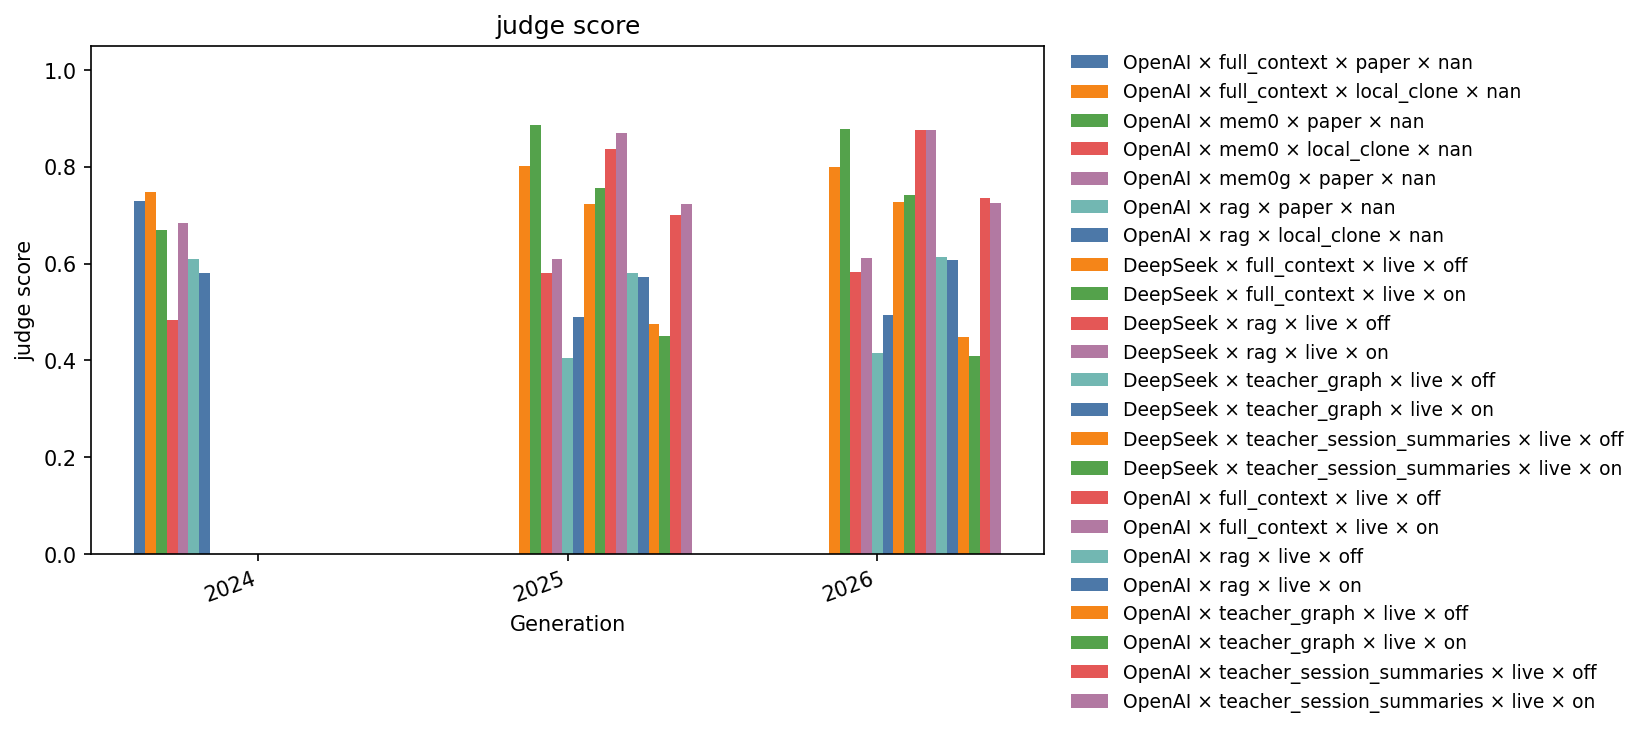

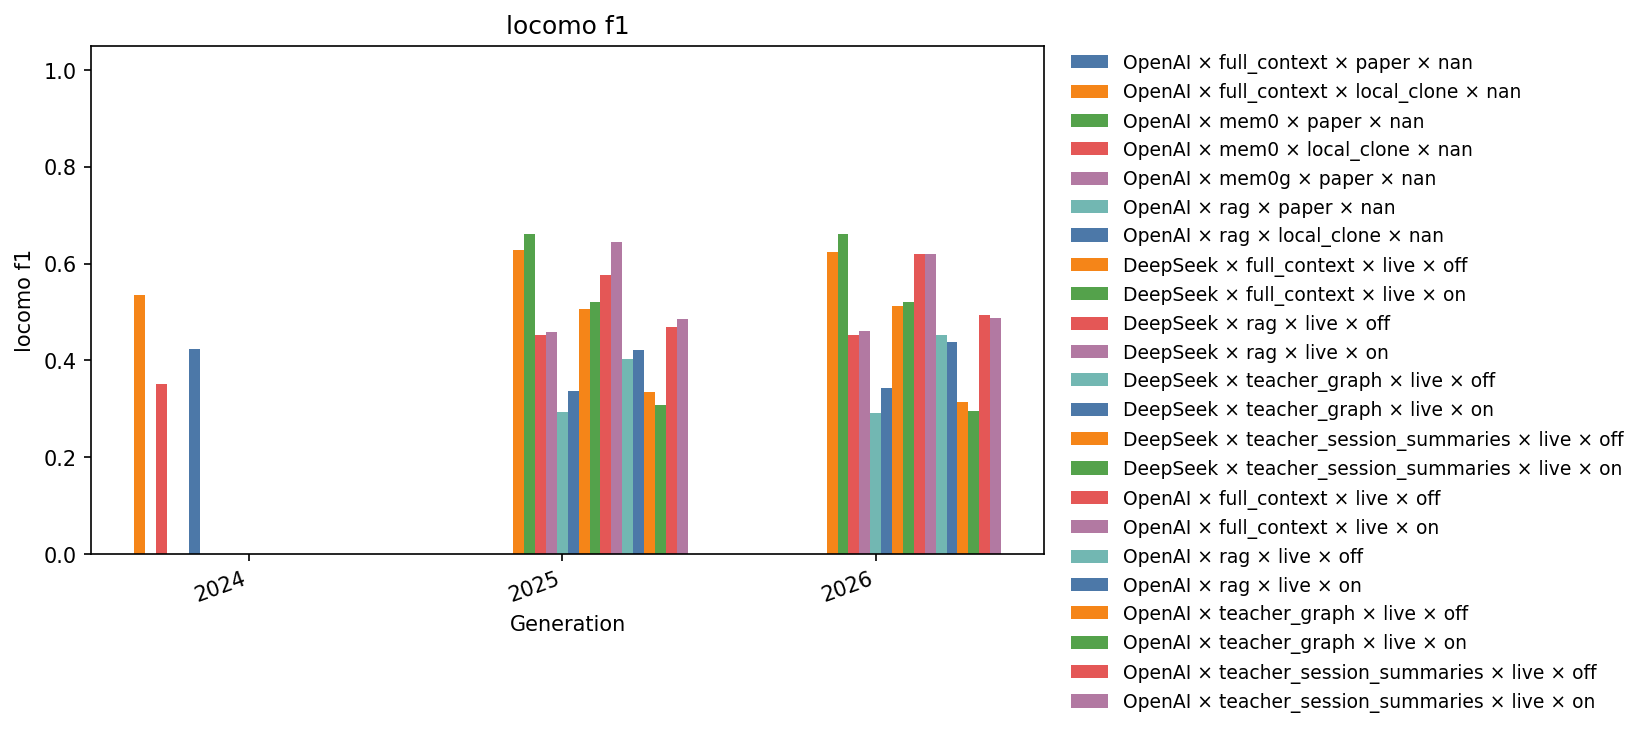

### Full-context J by generation and family

,generation,model_family,result_source,n,judge_score
0,2024,OpenAI,paper,1540,0.729000
1,2024,OpenAI,local_clone,1540,0.746800
2,2025,DeepSeek,live,3080,0.843831
3,2025,OpenAI,live,3080,0.852597
4,2026,DeepSeek,live,3080,0.838636
5,2026,OpenAI,live,3080,0.875974


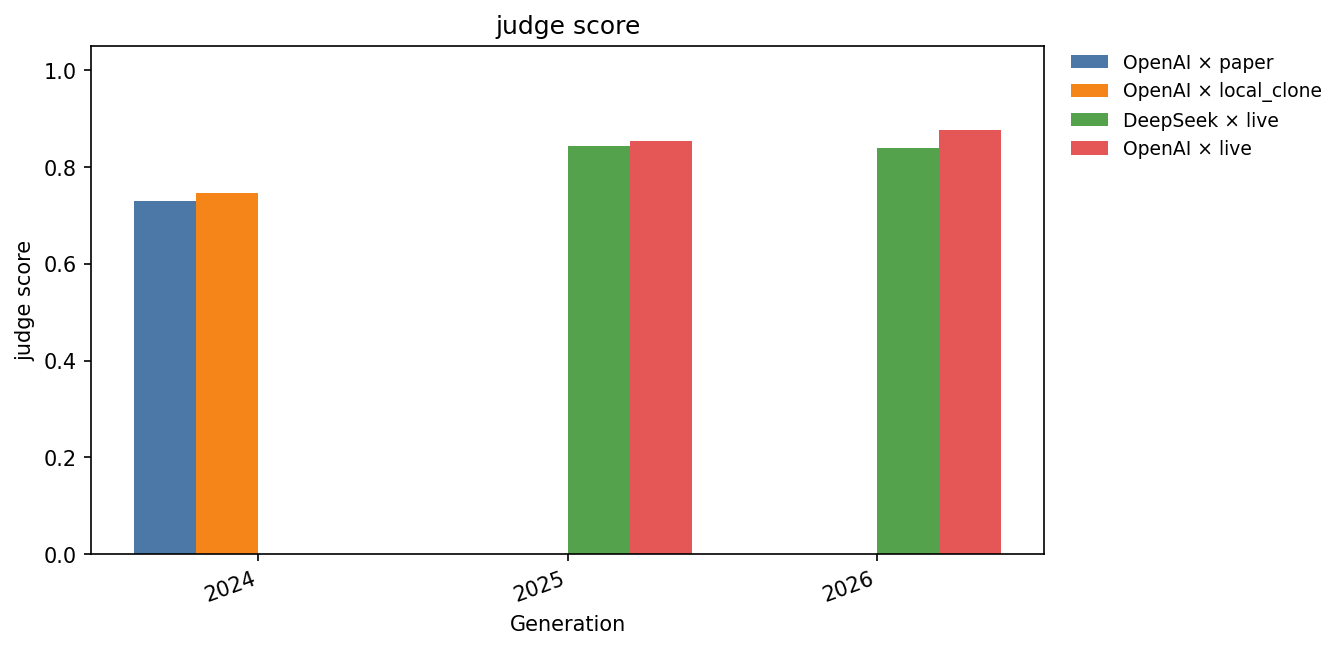

### RAG J by generation and family

,generation,model_family,result_source,n,judge_score
0,2024,OpenAI,paper,1540,0.609700
1,2024,OpenAI,local_clone,1540,0.579900
2,2025,DeepSeek,live,3080,0.595130
3,2025,OpenAI,live,3080,0.576299
4,2026,DeepSeek,live,3080,0.597078
5,2026,OpenAI,live,3080,0.610390


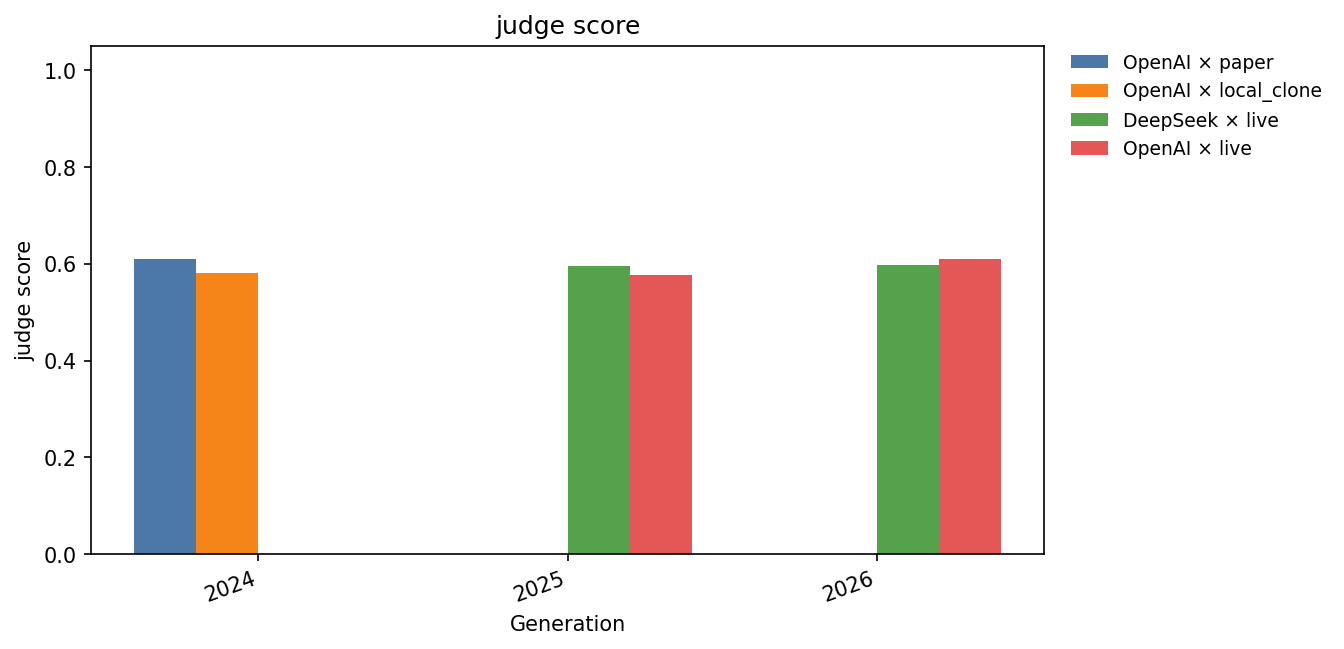

### Memory-construction J (paper Mem0 vs teacher writers)

,generation,model_family,memory_method,result_source,n,judge_score
0,2024,OpenAI,mem0,paper,1540,0.668800
1,2024,OpenAI,mem0,local_clone,1540,0.483800
2,2024,OpenAI,mem0g,paper,1540,0.684400
3,2025,DeepSeek,teacher_graph,live,3080,0.447727
4,2025,DeepSeek,teacher_session_summaries,live,3080,0.739286
5,2025,OpenAI,teacher_graph,live,3080,0.462987
6,2025,OpenAI,teacher_session_summaries,live,3080,0.711688
7,2026,DeepSeek,teacher_graph,live,3080,0.454870
8,2026,DeepSeek,teacher_session_summaries,live,3080,0.734740
9,2026,OpenAI,teacher_graph,live,3080,0.428896


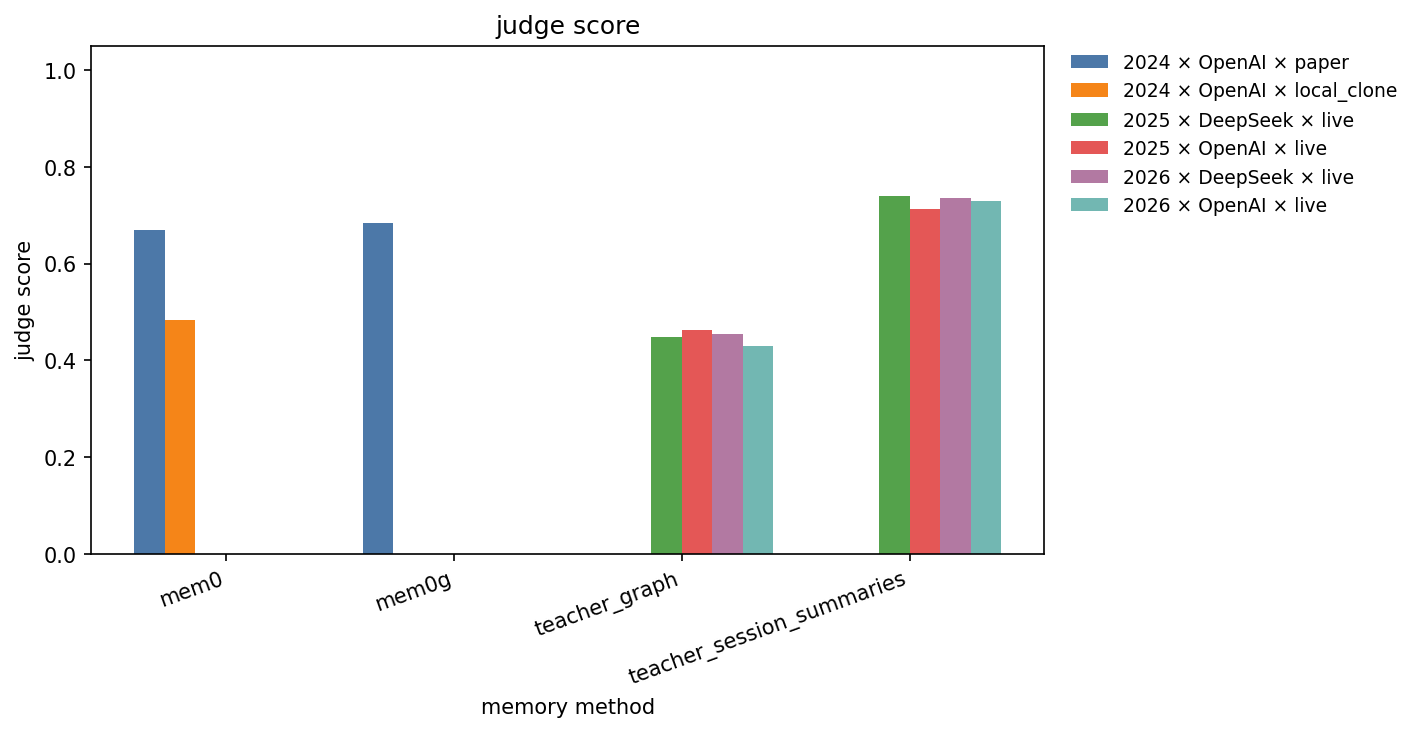

### Live reader 2025–2026 (matched sandwich; no 2024 pins)

,generation,model_family,memory_method,thinking,n,locomo_f1,judge_score
0,2025,DeepSeek,full_context,off,1540,0.628065,0.801299
1,2025,DeepSeek,full_context,on,1540,0.662028,0.886364
2,2025,DeepSeek,rag,off,1540,0.452969,0.580519
3,2025,DeepSeek,rag,on,1540,0.457641,0.609740
4,2025,OpenAI,full_context,off,1540,0.577370,0.835714
5,2025,OpenAI,full_context,on,1540,0.644642,0.869481
6,2025,OpenAI,rag,off,1540,0.403733,0.580519
7,2025,OpenAI,rag,on,1540,0.421588,0.572078
8,2026,DeepSeek,full_context,off,1540,0.624478,0.799351
9,2026,DeepSeek,full_context,on,1540,0.660554,0.877922


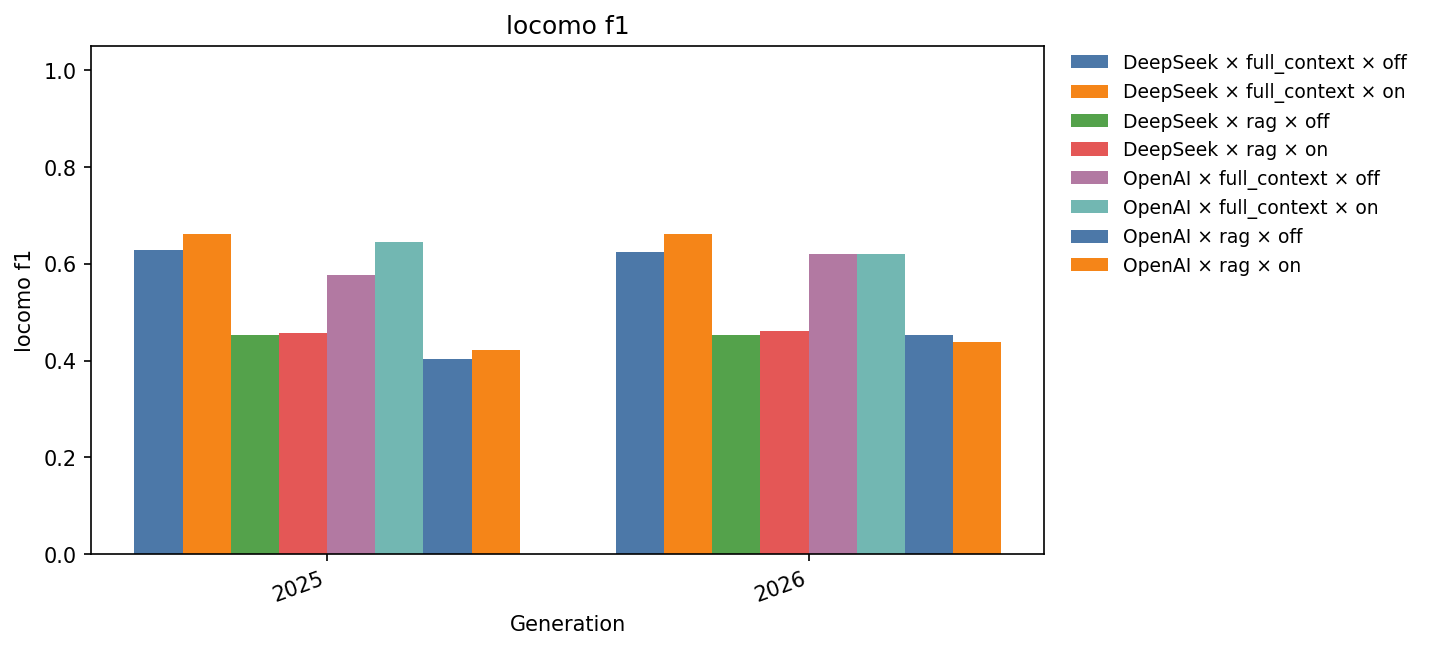

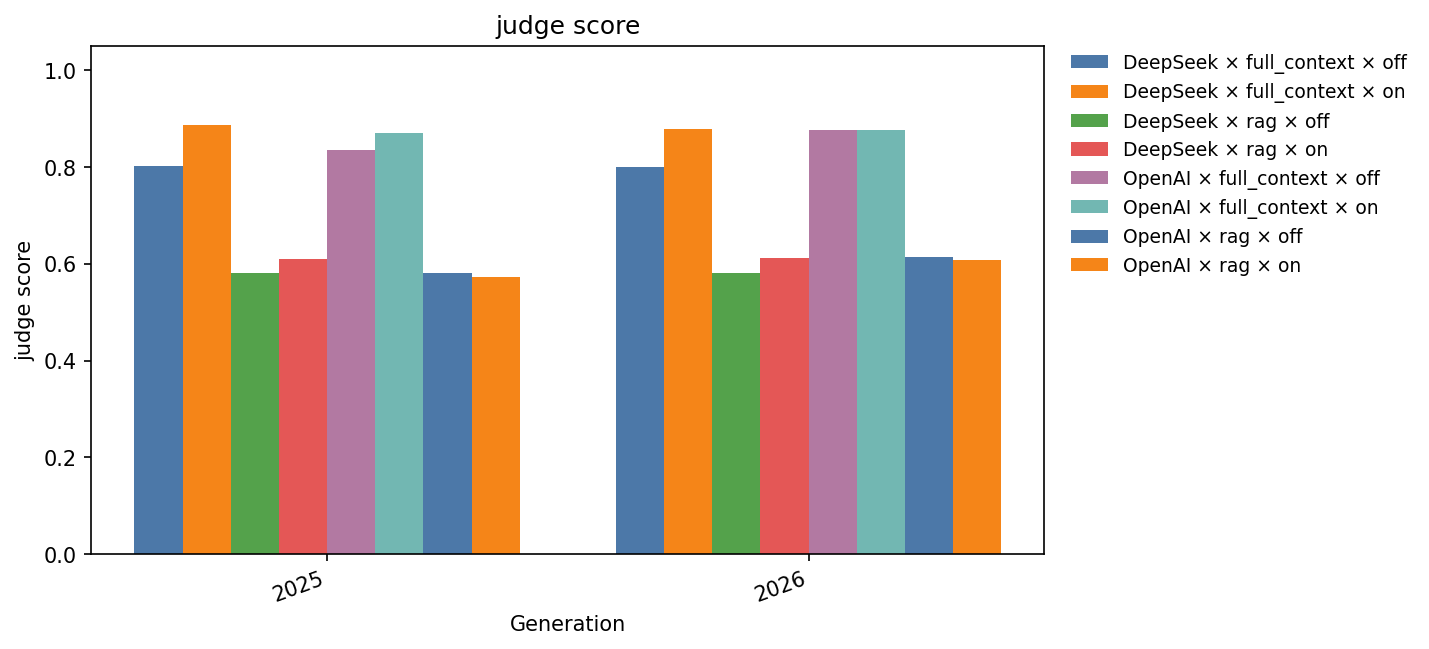

### Live writer 2025–2026 (frozen gpt-4o-mini reader)

,generation,model_family,memory_method,thinking,n,locomo_f1,judge_score
0,2025,DeepSeek,teacher_graph,off,1540,0.293937,0.405844
1,2025,DeepSeek,teacher_graph,on,1540,0.336740,0.489610
2,2025,DeepSeek,teacher_session_summaries,off,1540,0.505390,0.722078
3,2025,DeepSeek,teacher_session_summaries,on,1540,0.519740,0.756494
4,2025,OpenAI,teacher_graph,off,1540,0.334973,0.475325
5,2025,OpenAI,teacher_graph,on,1540,0.307738,0.450649
6,2025,OpenAI,teacher_session_summaries,off,1540,0.468820,0.700000
7,2025,OpenAI,teacher_session_summaries,on,1540,0.485972,0.723377
8,2026,DeepSeek,teacher_graph,off,1540,0.291146,0.415584
9,2026,DeepSeek,teacher_graph,on,1540,0.343497,0.494156


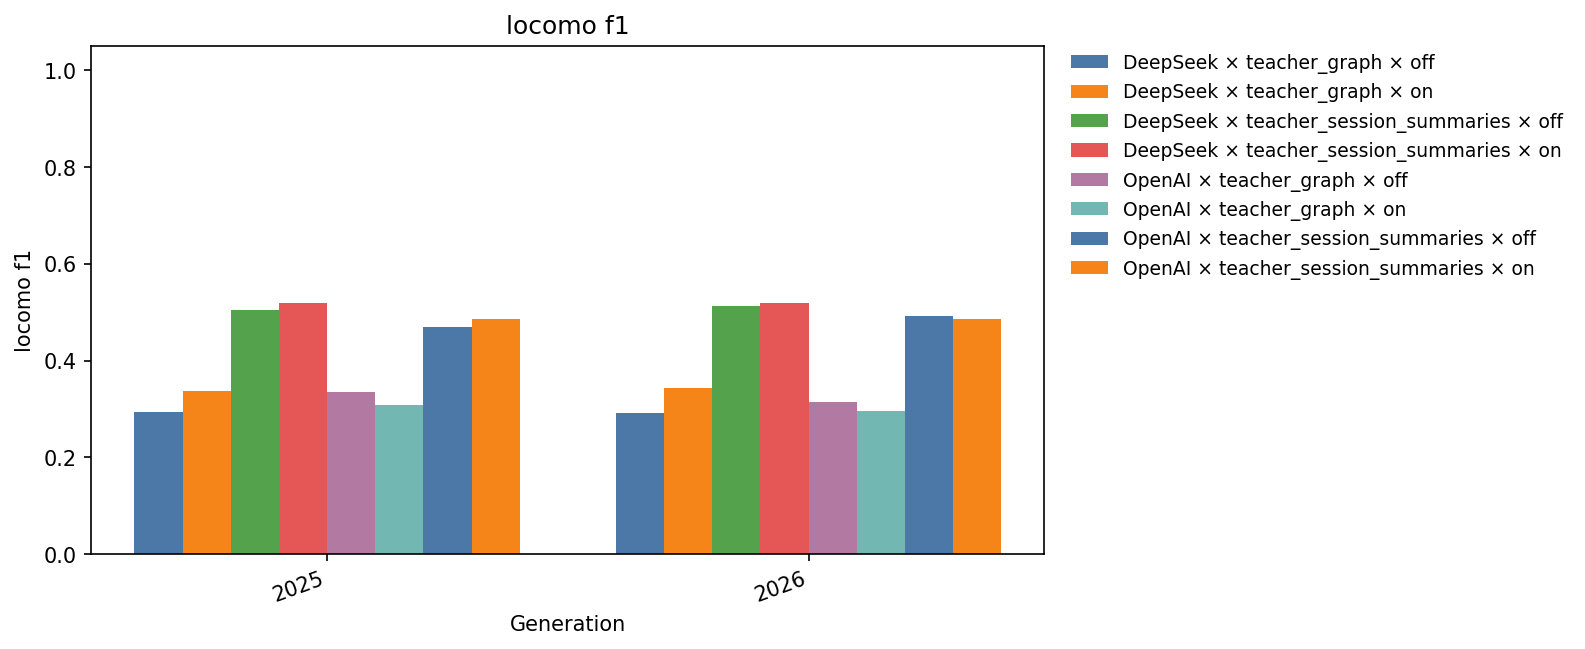

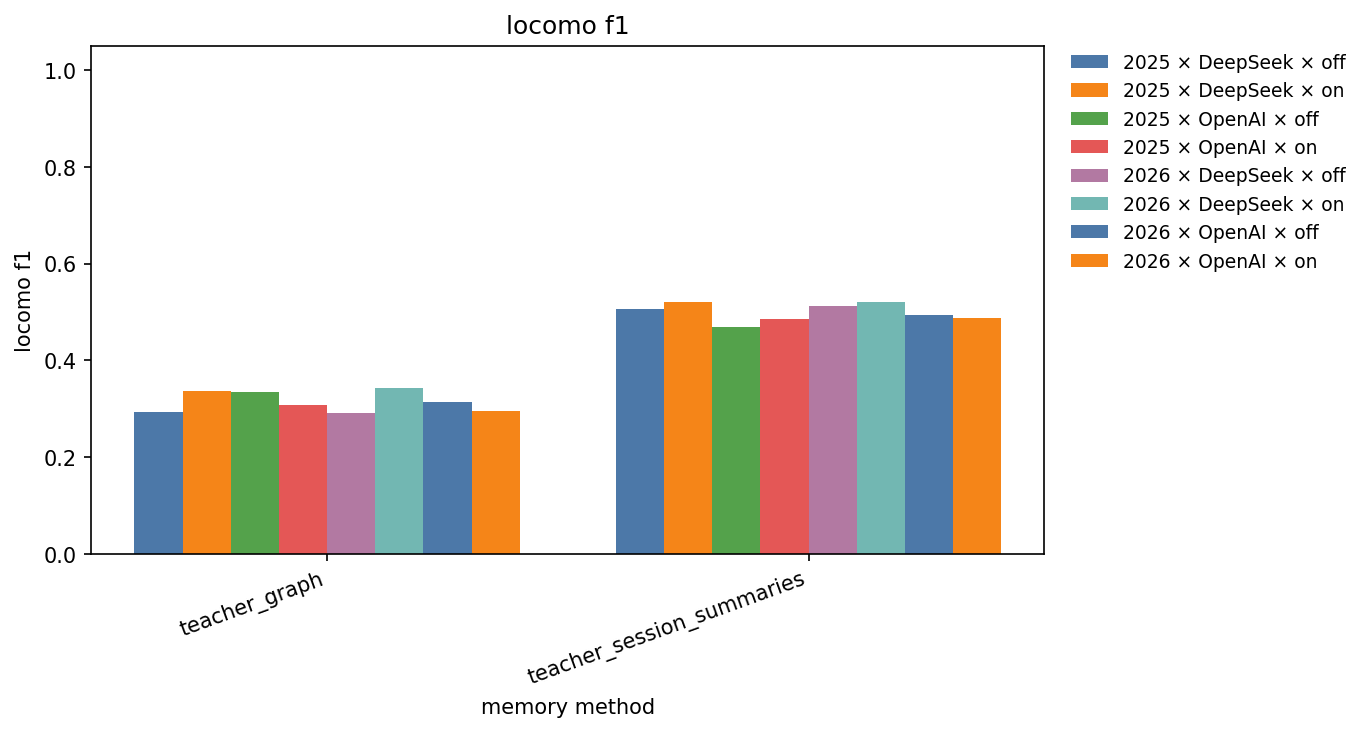

### Full-context category holes (thinking off)

_skipped: empty table_

### RAG category holes (thinking off)

_skipped: empty table_

### Writer category holes (thinking off; frozen reader)

_skipped: empty table_

### Year × family × thinking (J; live only)

,generation,model_family,memory_method,thinking,n,judge_score,locomo_f1
0,2025,DeepSeek,full_context,off,1540,0.801299,0.628065
1,2025,DeepSeek,full_context,on,1540,0.886364,0.662028
2,2025,DeepSeek,rag,off,1540,0.580519,0.452969
3,2025,DeepSeek,rag,on,1540,0.609740,0.457641
4,2025,DeepSeek,teacher_graph,off,1540,0.405844,0.293937
5,2025,DeepSeek,teacher_graph,on,1540,0.489610,0.336740
6,2025,DeepSeek,teacher_session_summaries,off,1540,0.722078,0.505390
7,2025,DeepSeek,teacher_session_summaries,on,1540,0.756494,0.519740
8,2025,OpenAI,full_context,off,1540,0.835714,0.577370
9,2025,OpenAI,full_context,on,1540,0.869481,0.644642


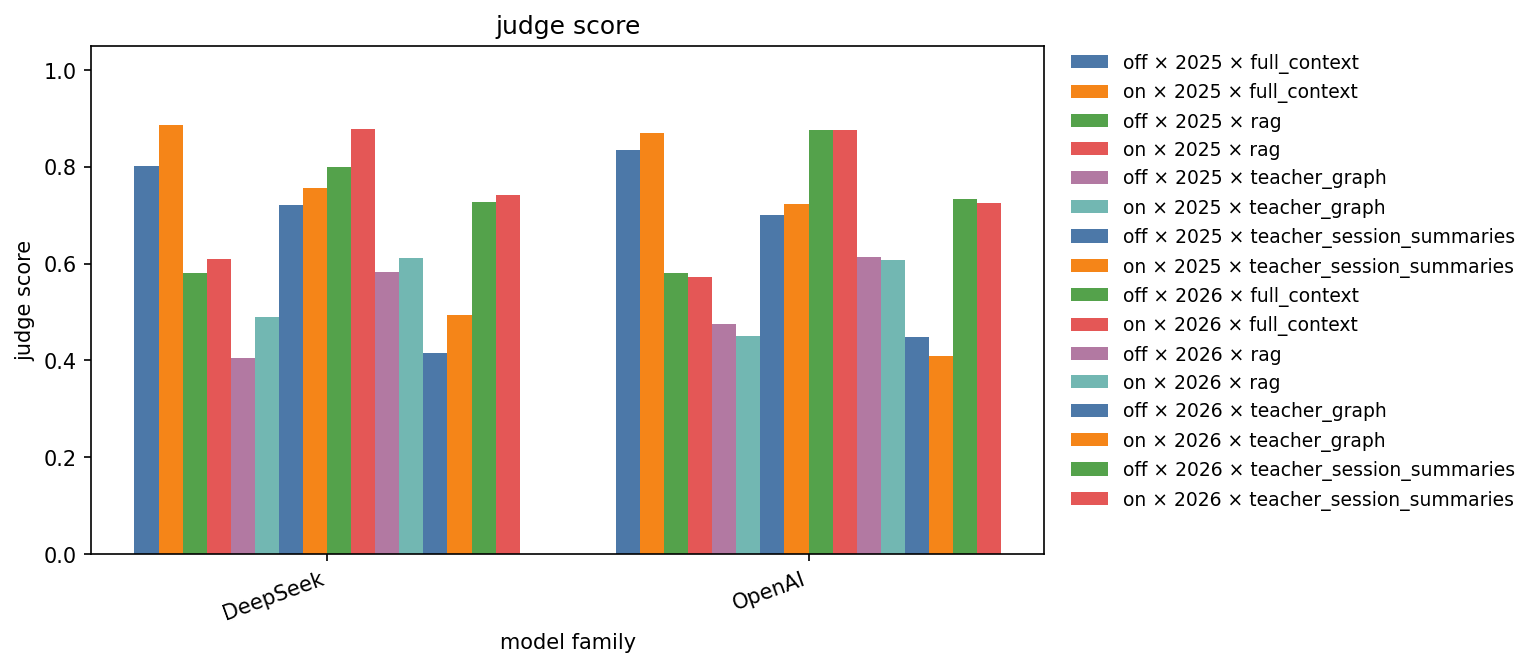

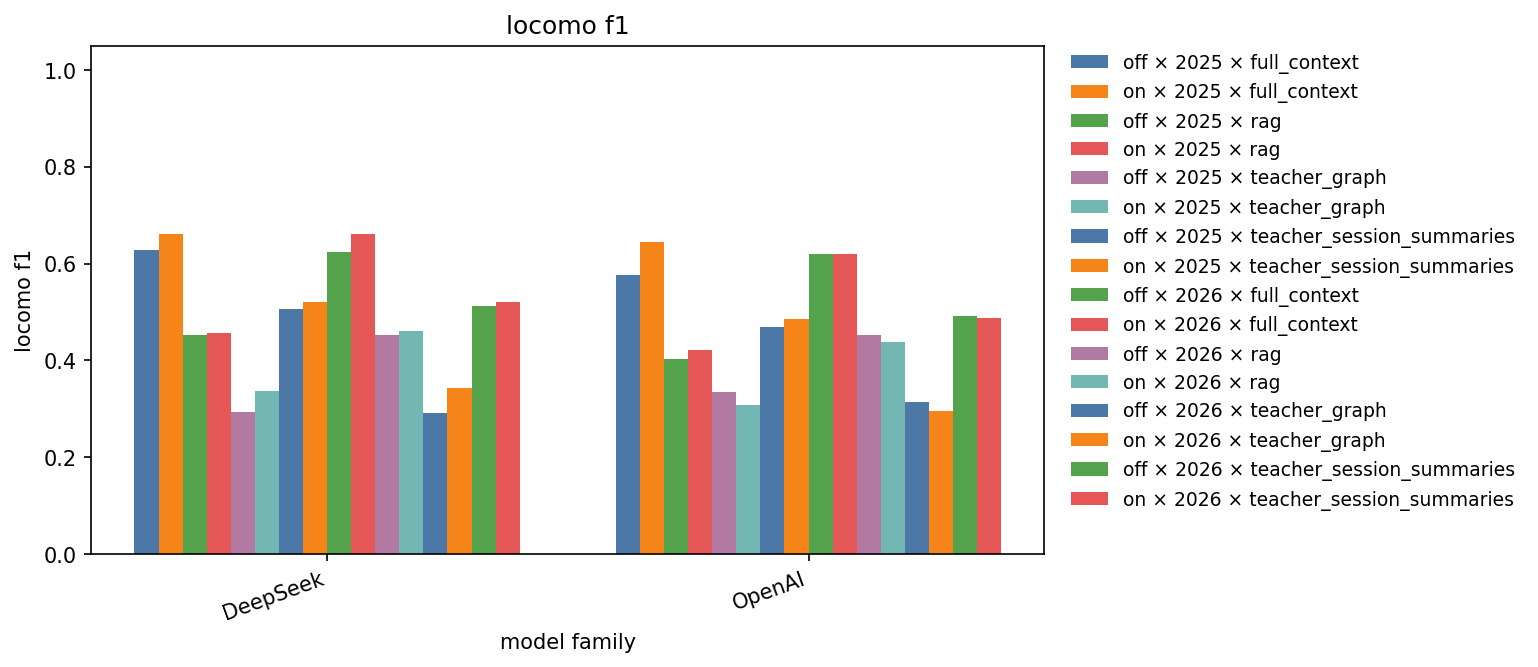

### Reader thinking-axis by year and family

,generation,model_family,memory_method,thinking,n,agent_reasoning_tokens,agent_latency_seconds
0,2025,DeepSeek,full_context,off,1540,NaN,1.275531
1,2025,DeepSeek,full_context,on,1540,608.008442,3.886721
2,2025,DeepSeek,rag,off,1540,NaN,0.898689
3,2025,DeepSeek,rag,on,1540,897.725325,5.104706
4,2025,OpenAI,full_context,off,1540,0.000000,2.389093
5,2025,OpenAI,full_context,on,1540,1281.496104,14.899670
6,2025,OpenAI,rag,off,1540,0.000000,1.745731
7,2025,OpenAI,rag,on,1540,1443.158442,14.297348
8,2026,DeepSeek,full_context,off,1540,NaN,1.129001
9,2026,DeepSeek,full_context,on,1540,590.251299,3.537805


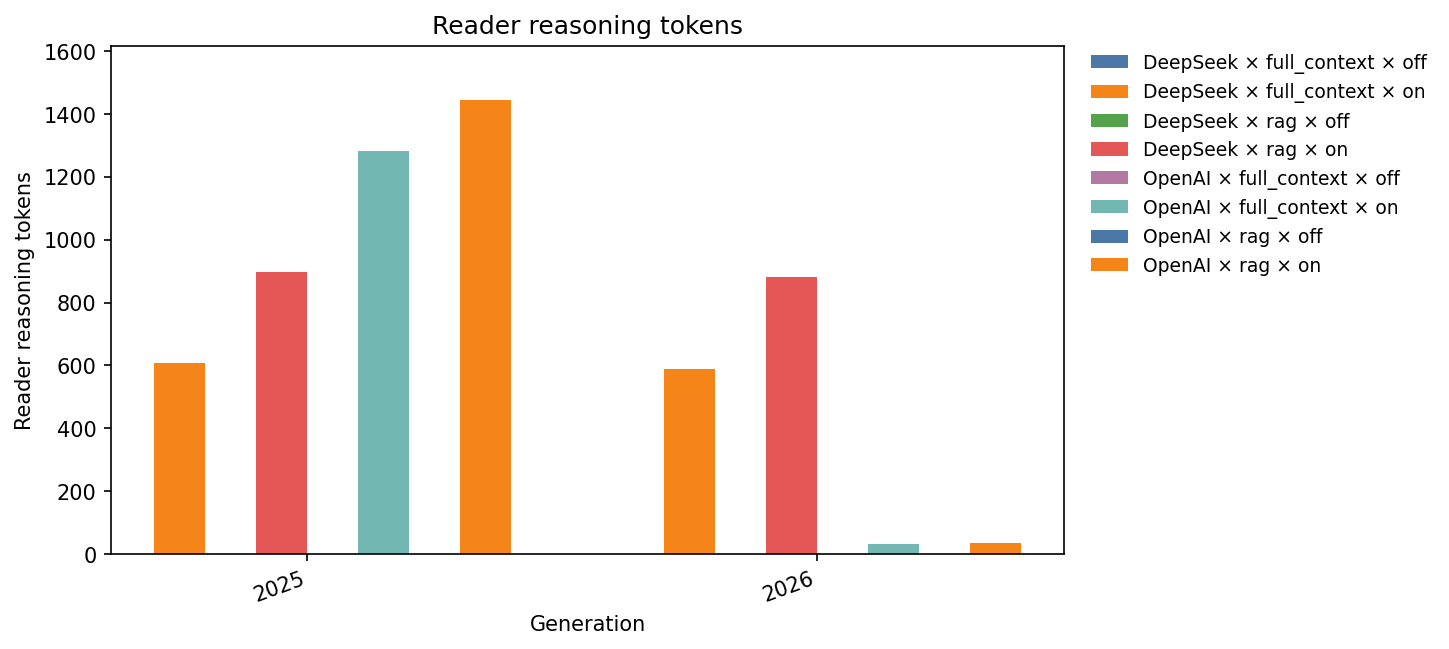

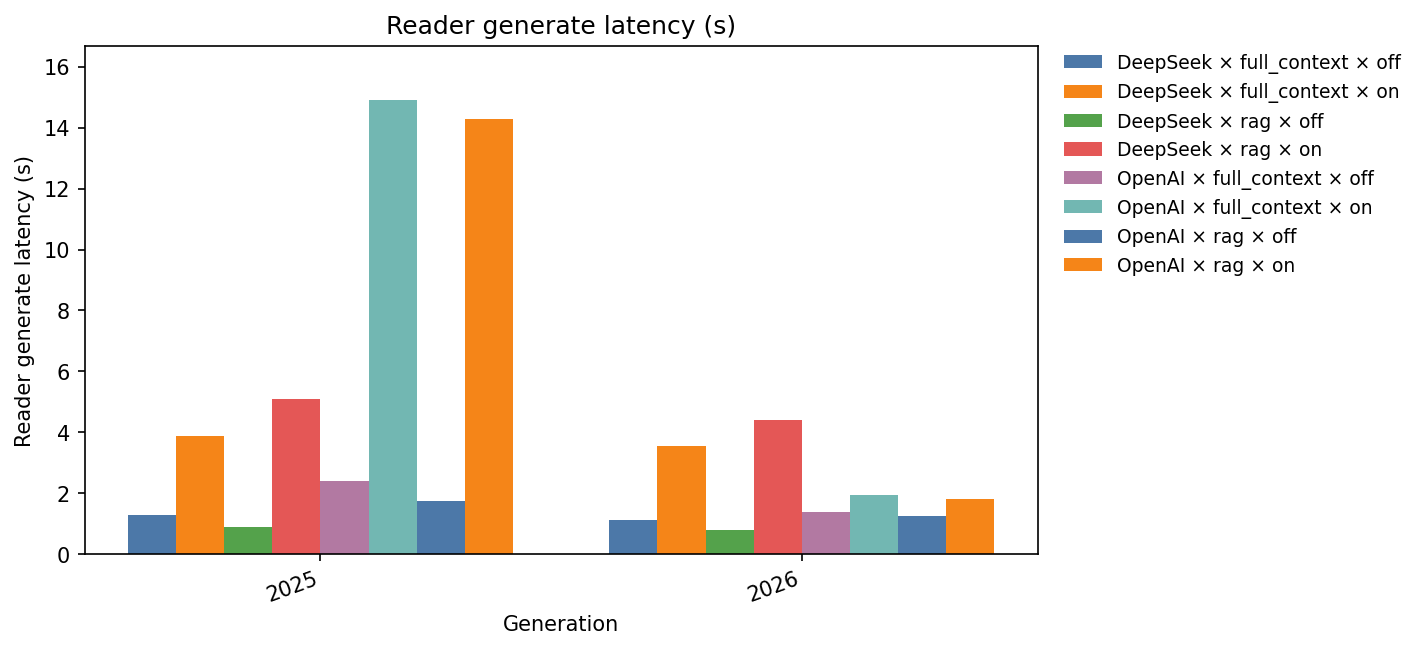

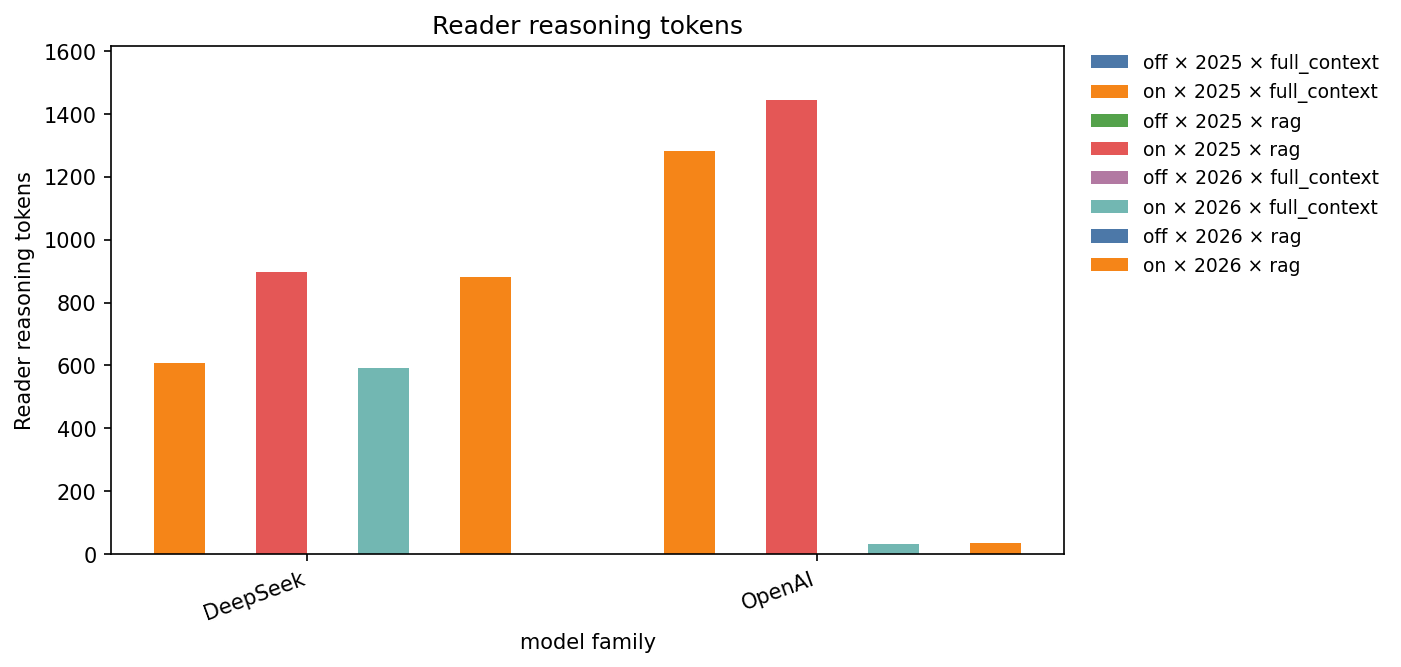

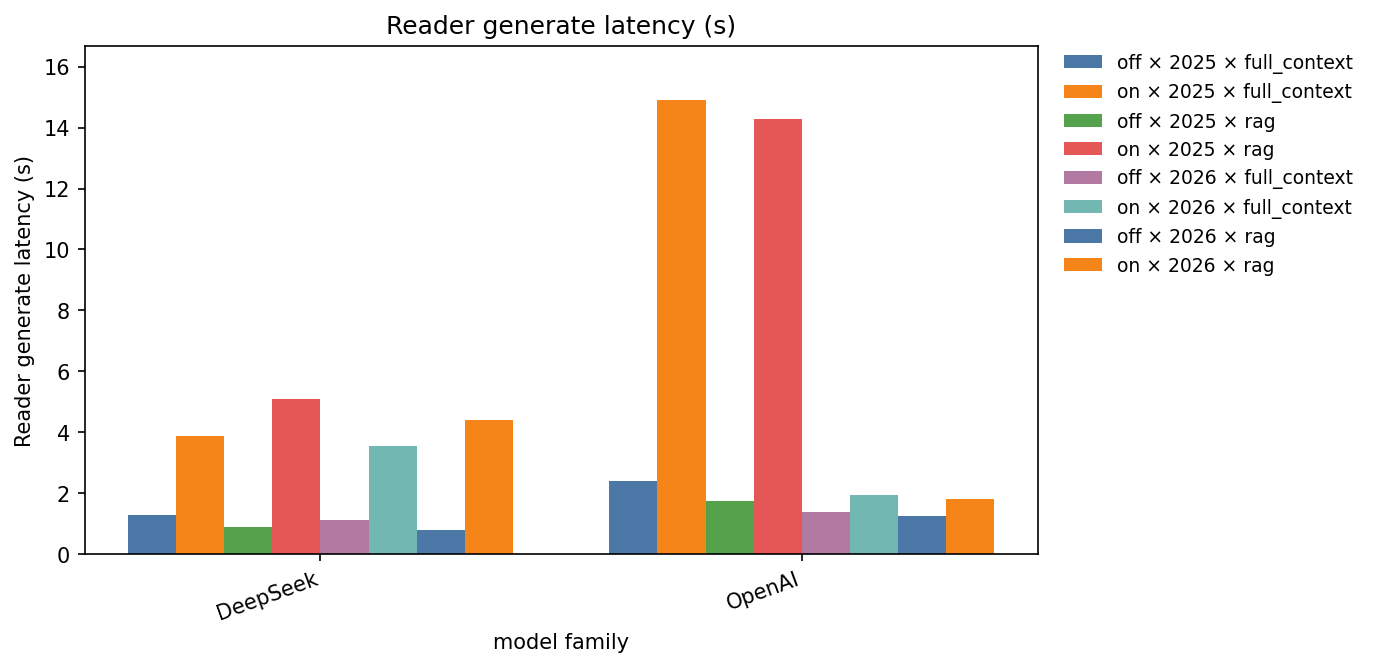

### Writer thinking-axis by year and family

,generation,model_family,memory_method,thinking,n,teacher_reasoning_tokens,teacher_latency_seconds
0,2025,DeepSeek,teacher_graph,off,1,0.0,2.4415
1,2025,DeepSeek,teacher_graph,on,1,2909944.0,50.1939
2,2025,DeepSeek,teacher_session_summaries,off,1,0.0,1.6470
3,2025,DeepSeek,teacher_session_summaries,on,1,250221.0,6.5737
4,2025,OpenAI,teacher_graph,off,1,0.0,4.2753
5,2025,OpenAI,teacher_graph,on,1,2153920.0,81.0317
6,2025,OpenAI,teacher_session_summaries,off,1,0.0,2.3158
7,2025,OpenAI,teacher_session_summaries,on,1,564096.0,23.2443
8,2026,DeepSeek,teacher_graph,off,1,0.0,2.5303
9,2026,DeepSeek,teacher_graph,on,1,2915025.0,45.7841


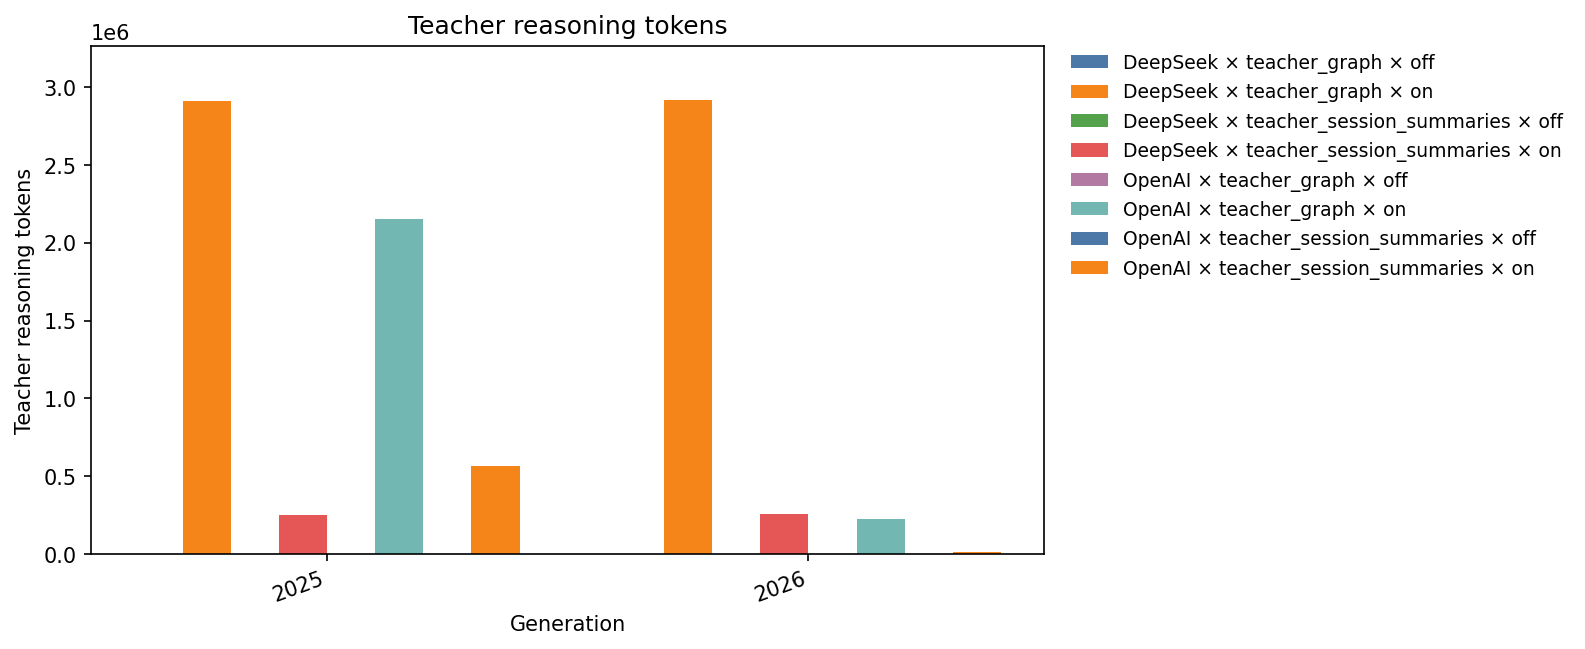

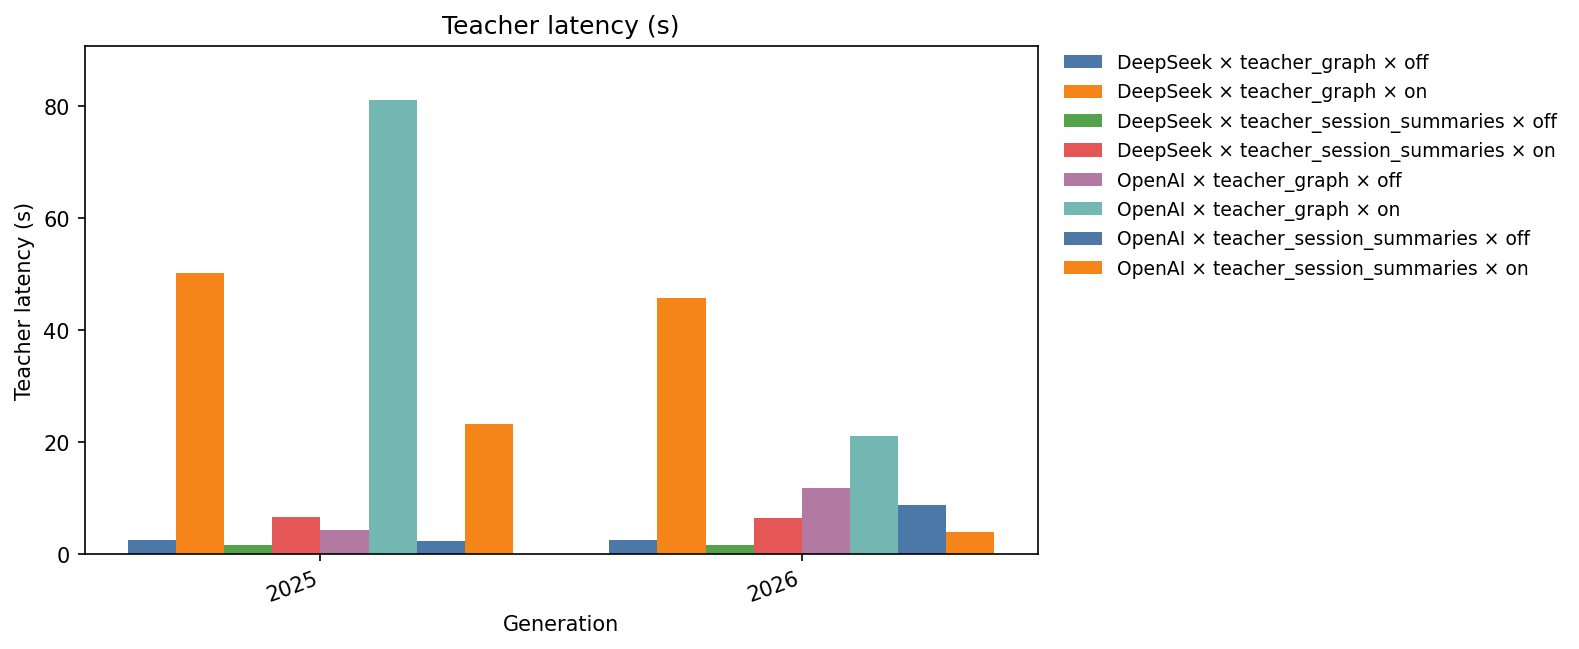

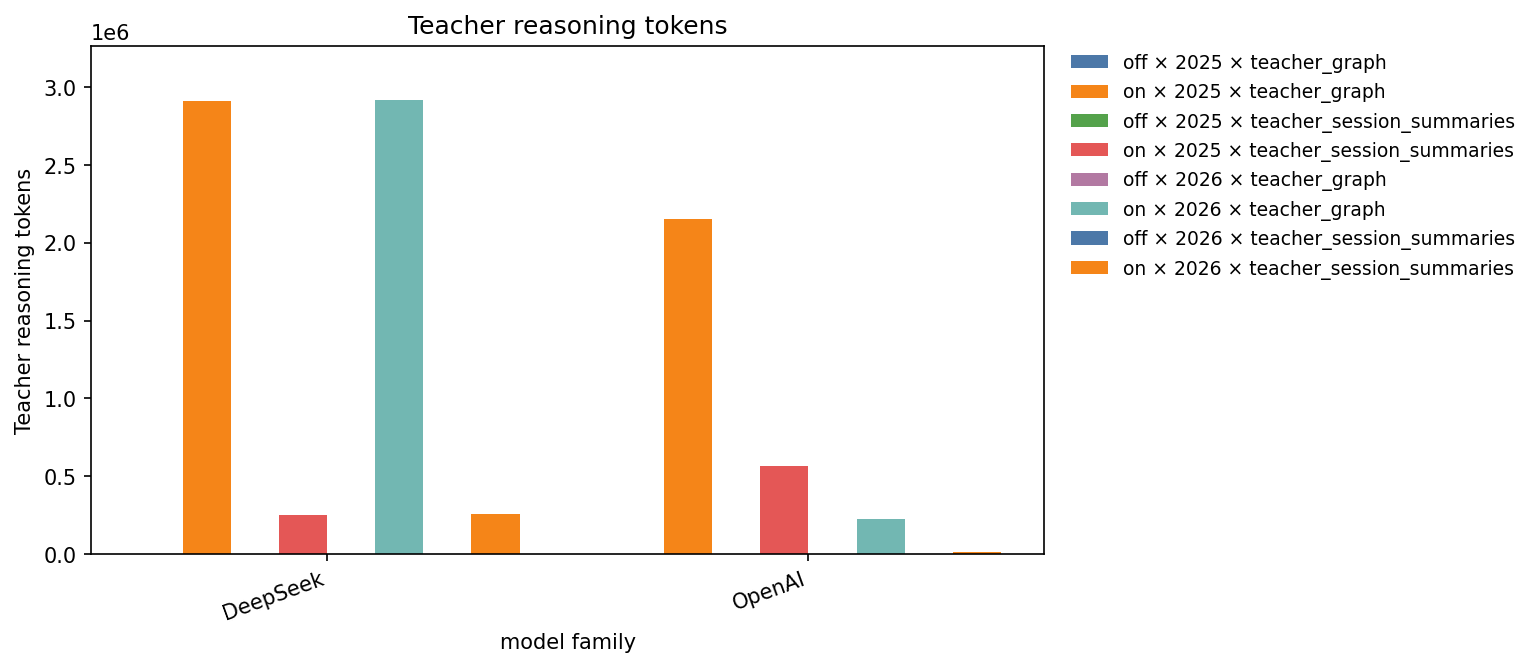

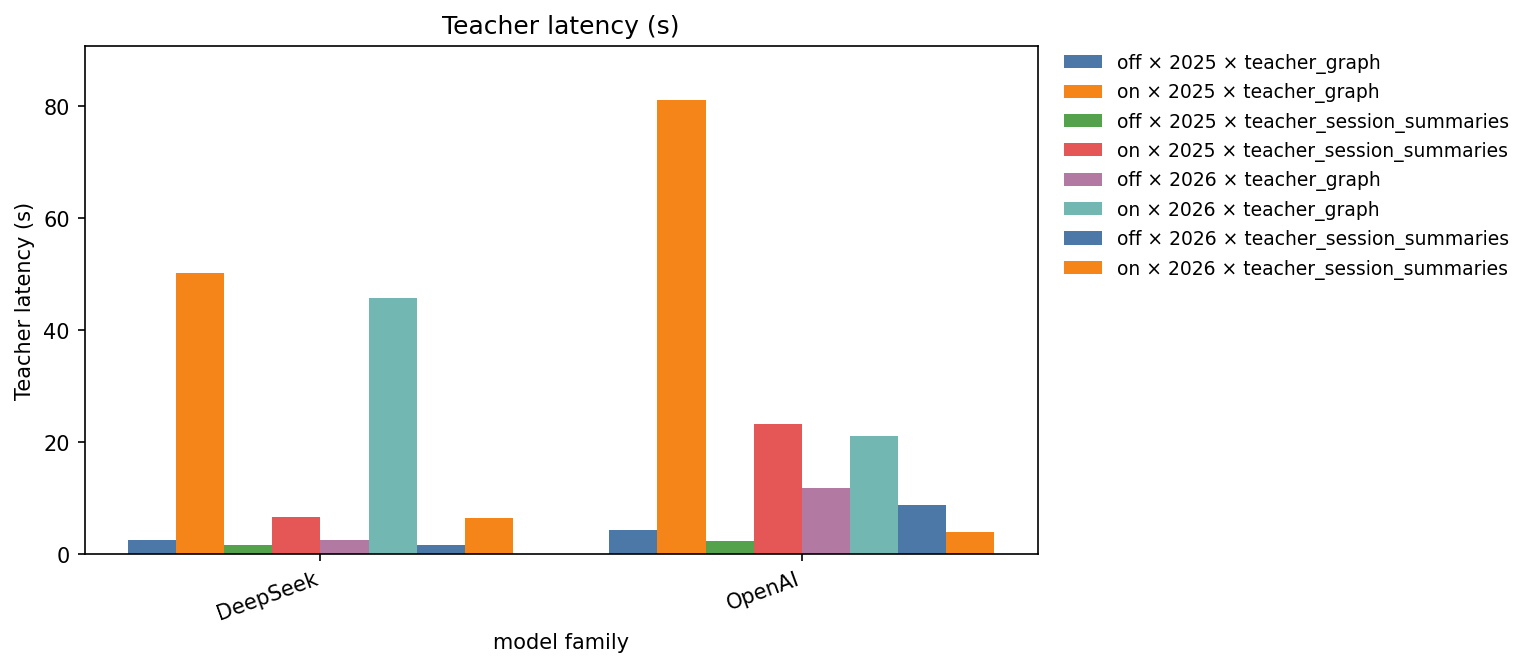

### Reader latency by year (generate + Mem0 search/total)

,generation,model_family,memory_method,thinking,n,agent_latency_seconds,total_latency_seconds_p50,total_latency_seconds_p95,search_latency_seconds_p50,search_latency_seconds_p95
0,2025,DeepSeek,full_context,off,1540,1.275531,1.255000,1.710100,0.000000,0.000000
1,2025,DeepSeek,full_context,on,1540,3.886721,2.113000,14.026100,0.000000,0.000000
2,2025,DeepSeek,rag,off,1540,0.898689,0.882500,1.132100,NaN,NaN
3,2025,DeepSeek,rag,on,1540,5.104706,1.945000,21.032800,NaN,NaN
4,2025,OpenAI,full_context,off,1540,2.389093,1.222500,6.579150,0.000000,0.000000
5,2025,OpenAI,full_context,on,1540,14.899670,10.938000,39.118400,0.000000,0.000000
6,2025,OpenAI,rag,off,1540,1.745731,1.015500,2.832300,NaN,NaN
7,2025,OpenAI,rag,on,1540,14.297348,11.353000,34.129550,NaN,NaN
8,2026,DeepSeek,full_context,off,1540,1.129001,1.114500,1.405050,0.000000,0.000000
9,2026,DeepSeek,full_context,on,1540,3.537805,1.941500,11.855000,0.000000,0.000000


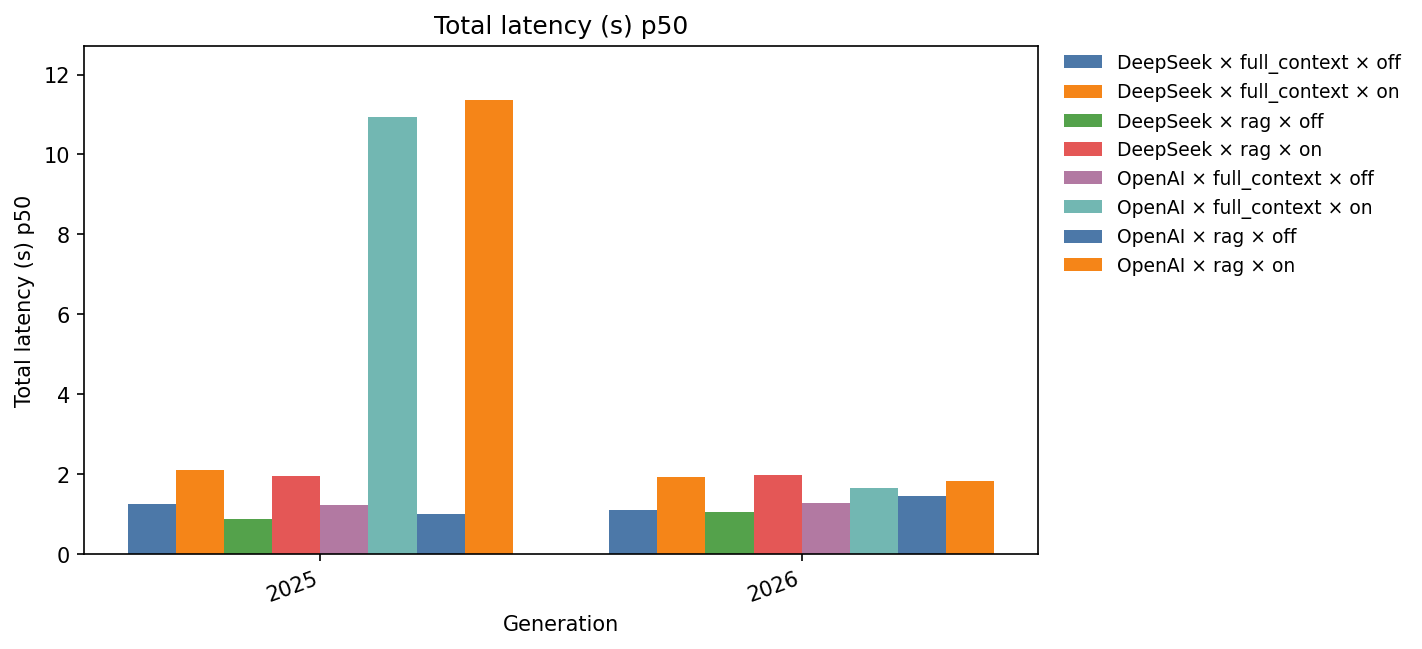

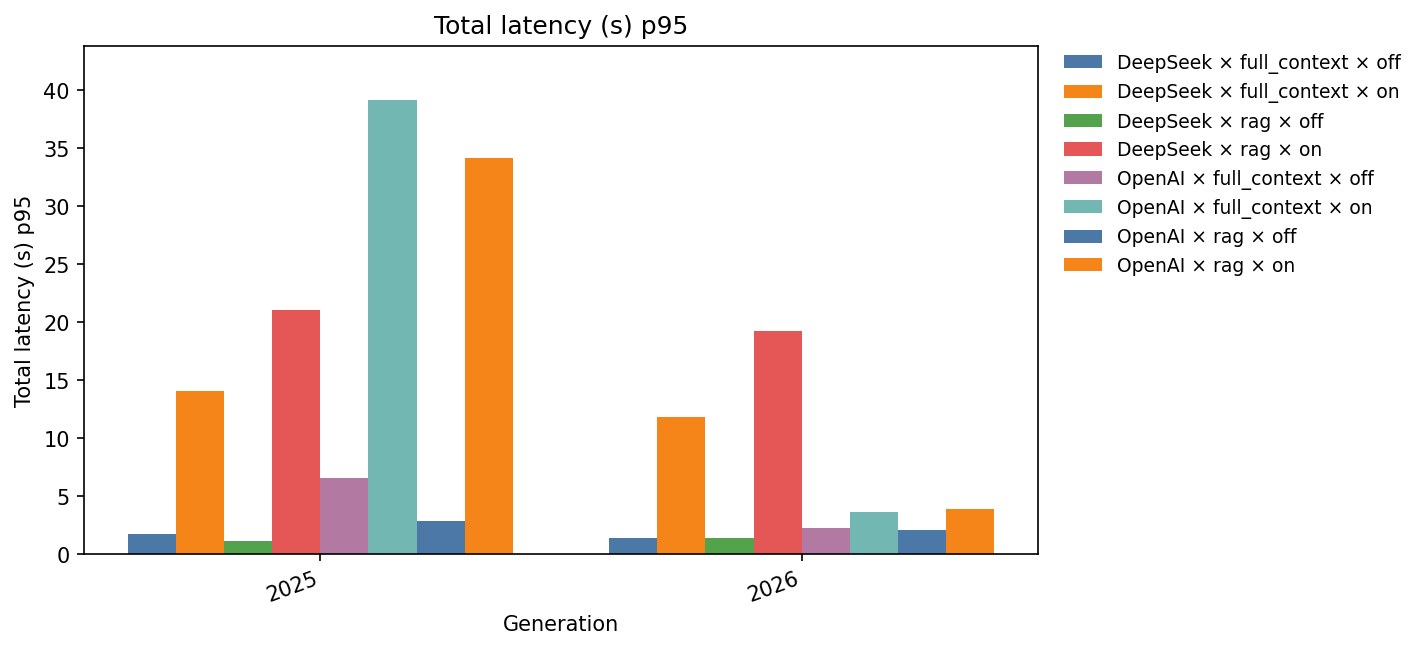

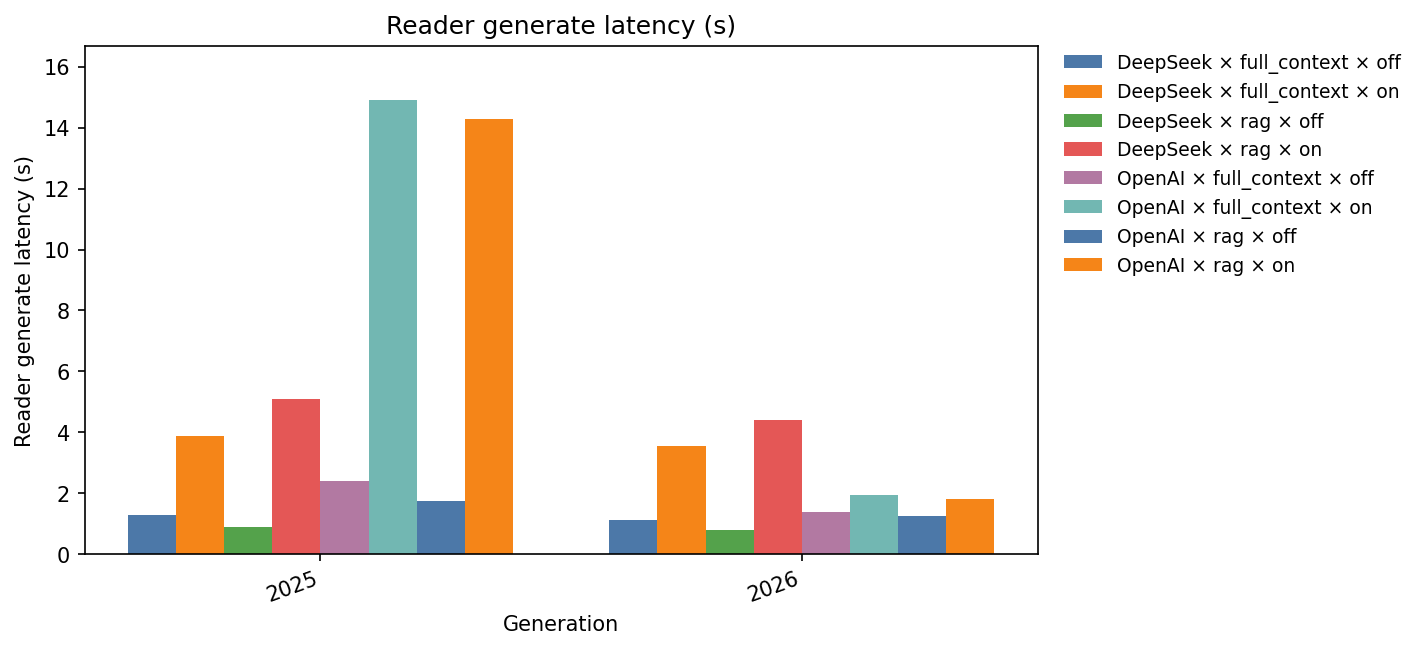

### Frozen-reader generate latency by writer year

,generation,model_family,memory_method,thinking,n,agent_latency_seconds,total_latency_seconds_p50,total_latency_seconds_p95
0,2025,DeepSeek,teacher_graph,off,1540,0.629712,0.5550,0.77405
1,2025,DeepSeek,teacher_graph,on,1540,0.629536,0.5985,0.83600
2,2025,DeepSeek,teacher_session_summaries,off,1540,0.639303,0.5800,0.83900
3,2025,DeepSeek,teacher_session_summaries,on,1540,0.676532,0.6060,0.88400
4,2025,OpenAI,teacher_graph,off,1540,0.595854,0.5540,0.81210
5,2025,OpenAI,teacher_graph,on,1540,0.627381,0.5800,0.84405
6,2025,OpenAI,teacher_session_summaries,off,1540,0.626844,0.5750,0.82245
7,2025,OpenAI,teacher_session_summaries,on,1540,0.626458,0.5890,0.83420
8,2026,DeepSeek,teacher_graph,off,1540,0.665103,0.6115,0.94905
9,2026,DeepSeek,teacher_graph,on,1540,0.739895,0.6500,1.14915


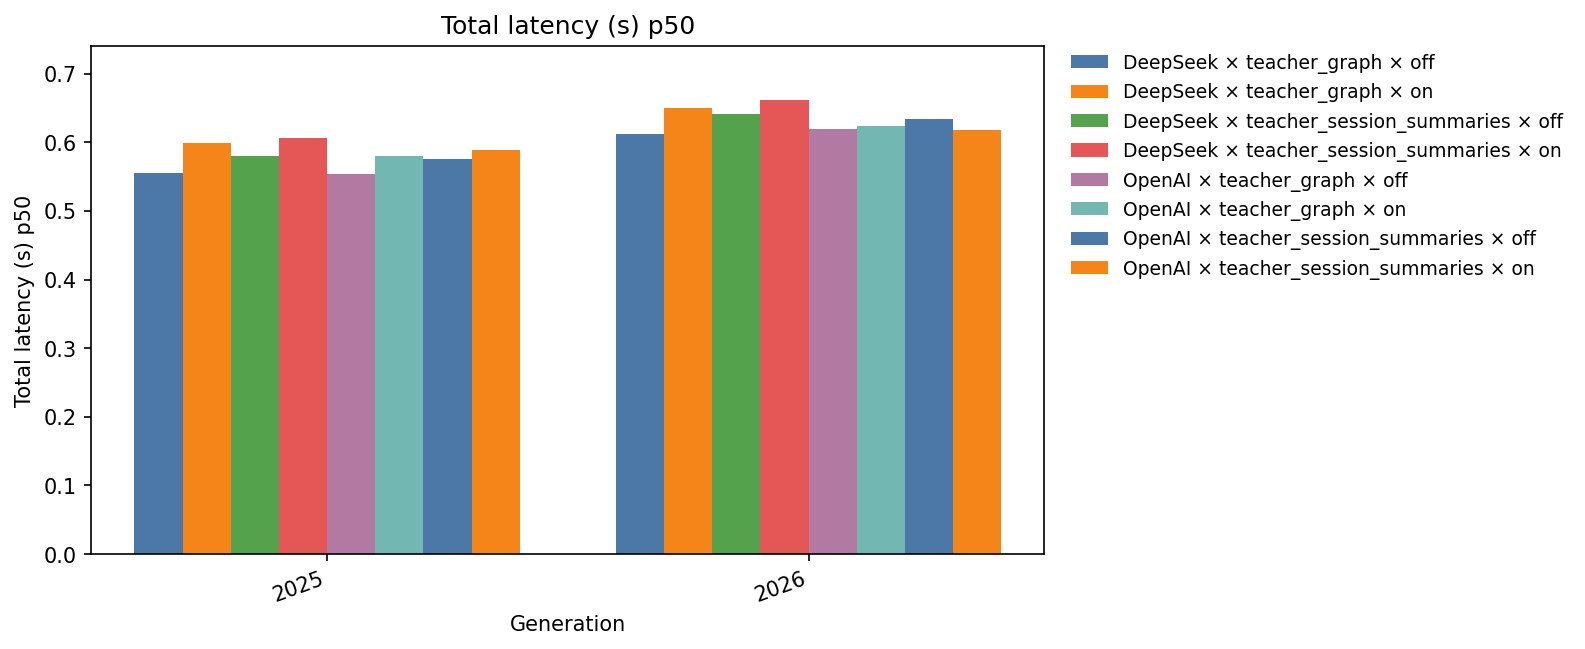

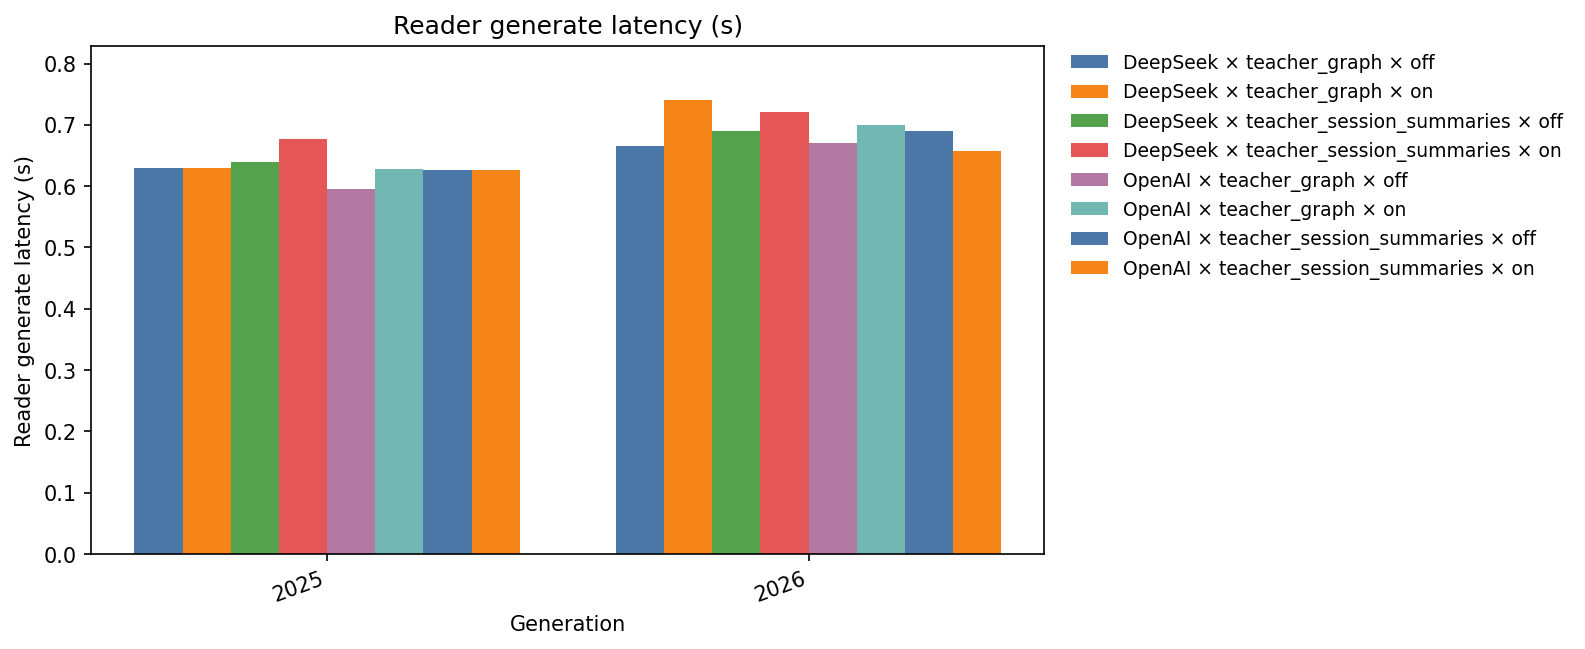

### Reader quality with latency and reasoning tokens (ROI inputs)

,generation,model_family,memory_method,thinking,n,locomo_f1,judge_score,agent_latency_seconds,agent_reasoning_tokens
0,2025,DeepSeek,full_context,off,1540,0.628065,0.801299,1.275531,NaN
1,2025,DeepSeek,full_context,on,1540,0.662028,0.886364,3.886721,608.008442
2,2025,DeepSeek,rag,off,1540,0.452969,0.580519,0.898689,NaN
3,2025,DeepSeek,rag,on,1540,0.457641,0.609740,5.104706,897.725325
4,2025,OpenAI,full_context,off,1540,0.577370,0.835714,2.389093,0.000000
5,2025,OpenAI,full_context,on,1540,0.644642,0.869481,14.899670,1281.496104
6,2025,OpenAI,rag,off,1540,0.403733,0.580519,1.745731,0.000000
7,2025,OpenAI,rag,on,1540,0.421588,0.572078,14.297348,1443.158442
8,2026,DeepSeek,full_context,off,1540,0.624478,0.799351,1.129001,NaN
9,2026,DeepSeek,full_context,on,1540,0.660554,0.877922,3.537805,590.251299


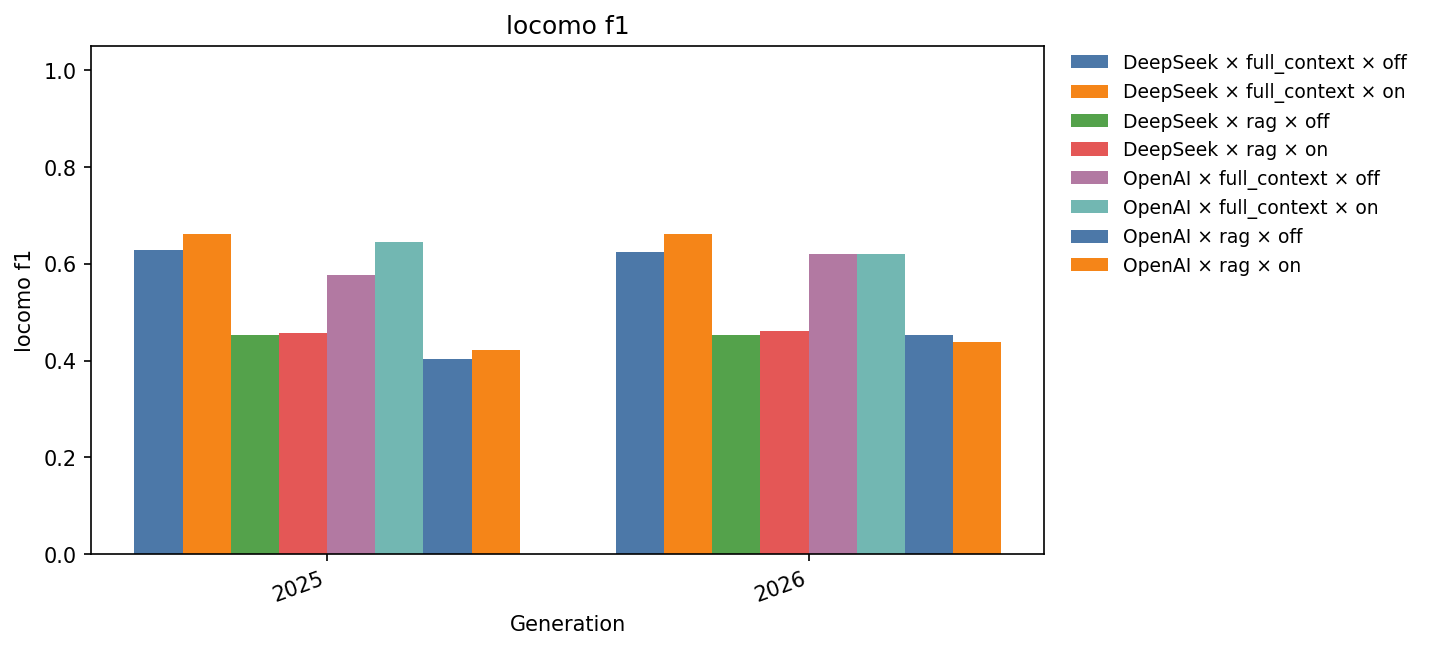

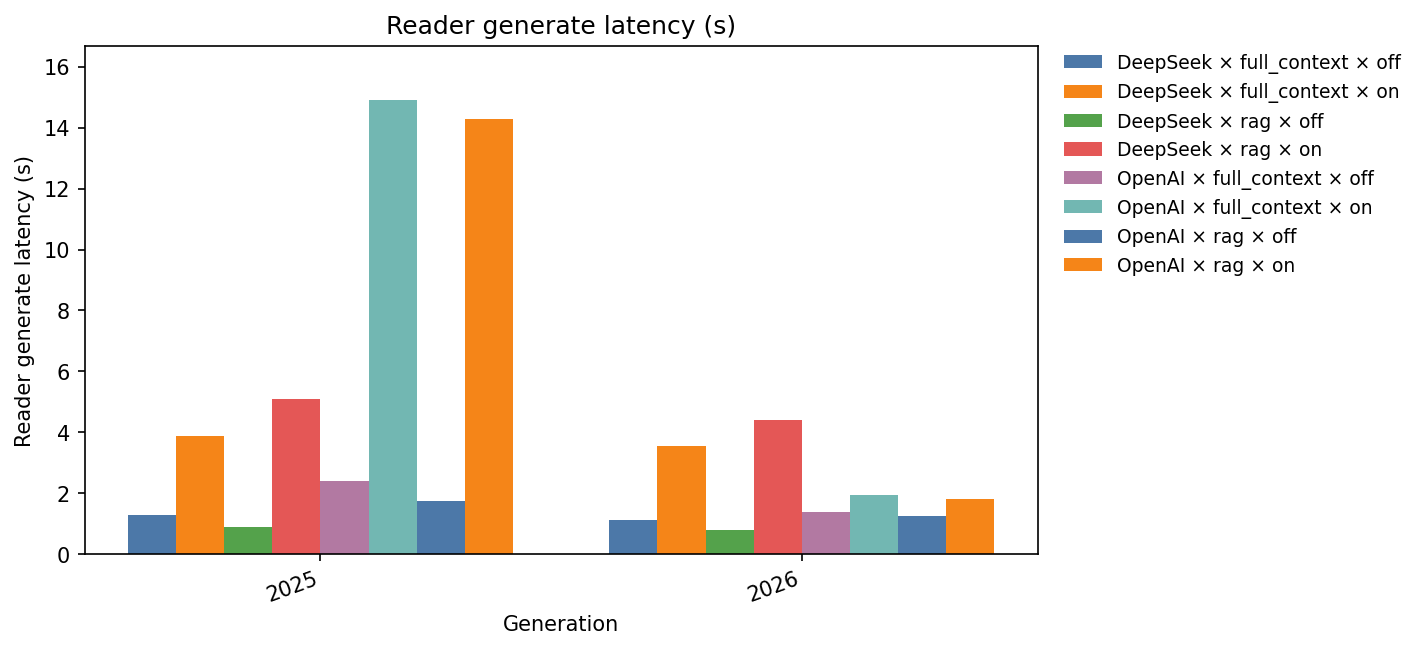

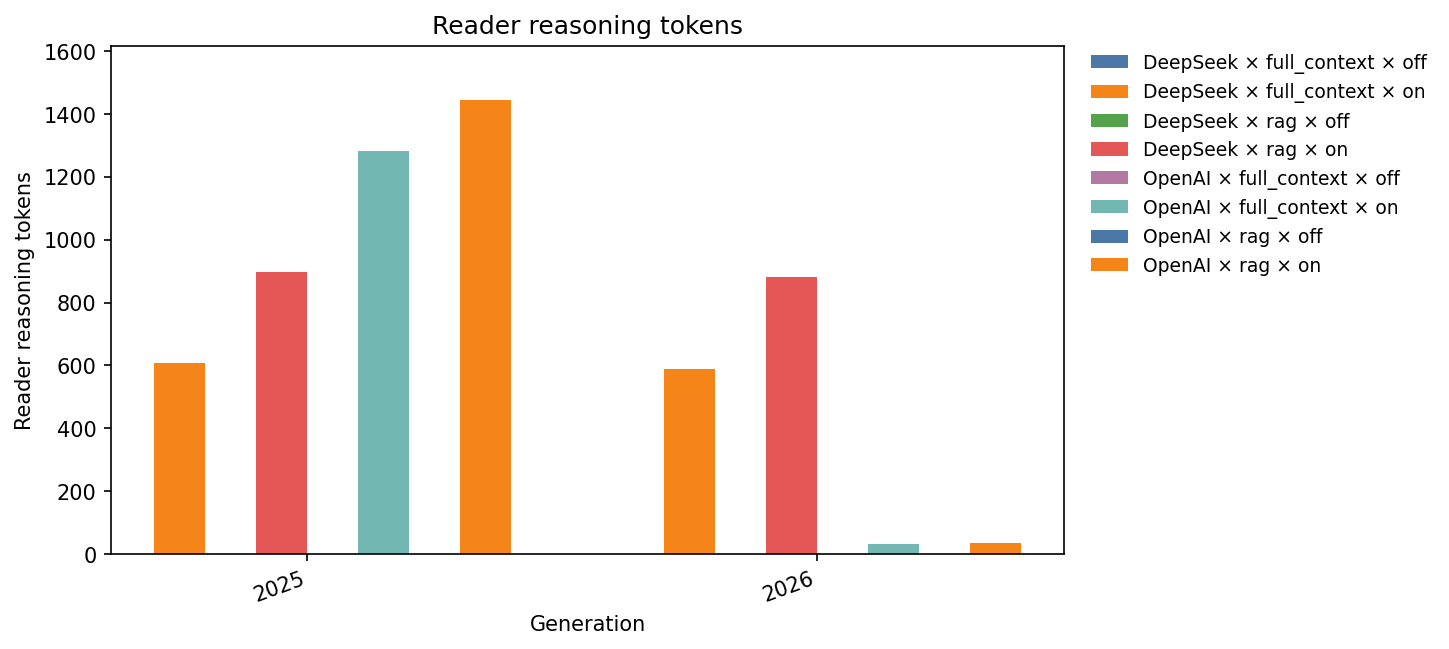

### Within-family year moves (live readers)

,model_family,memory_method,thinking,metric,from_generation,to_generation,from_value,to_value,delta,move
0,DeepSeek,full_context,off,locomo_f1,2025,2026,0.628065,0.624478,-0.003587,not_moving
1,DeepSeek,full_context,off,judge_score,2025,2026,0.801299,0.799351,-0.001948,not_moving
2,DeepSeek,full_context,on,locomo_f1,2025,2026,0.662028,0.660554,-0.001474,not_moving
3,DeepSeek,full_context,on,judge_score,2025,2026,0.886364,0.877922,-0.008442,not_moving
4,DeepSeek,rag,off,locomo_f1,2025,2026,0.452969,0.452584,-0.000385,not_moving
5,DeepSeek,rag,off,judge_score,2025,2026,0.580519,0.581818,0.001299,not_moving
6,DeepSeek,rag,on,locomo_f1,2025,2026,0.457641,0.461300,0.003659,not_moving
7,DeepSeek,rag,on,judge_score,2025,2026,0.609740,0.612338,0.002597,not_moving
8,OpenAI,full_context,off,locomo_f1,2025,2026,0.577370,0.620523,0.043153,improving
9,OpenAI,full_context,off,judge_score,2025,2026,0.835714,0.875325,0.039610,improving


### OpenAI − DeepSeek reader gaps (closing vs widening)

,memory_method,thinking,metric,generation,left_family,right_family,left_value,right_value,gap,from_generation,gap_move
0,full_context,off,locomo_f1,2025,OpenAI,DeepSeek,0.577370,0.628065,-0.050695,None,missing
1,full_context,off,locomo_f1,2026,OpenAI,DeepSeek,0.620523,0.624478,-0.003955,2025,gap_closing
2,full_context,off,judge_score,2025,OpenAI,DeepSeek,0.835714,0.801299,0.034416,None,missing
3,full_context,off,judge_score,2026,OpenAI,DeepSeek,0.875325,0.799351,0.075974,2025,gap_widening
4,full_context,on,locomo_f1,2025,OpenAI,DeepSeek,0.644642,0.662028,-0.017386,None,missing
5,full_context,on,locomo_f1,2026,OpenAI,DeepSeek,0.620429,0.660554,-0.040125,2025,gap_widening
6,full_context,on,judge_score,2025,OpenAI,DeepSeek,0.869481,0.886364,-0.016883,None,missing
7,full_context,on,judge_score,2026,OpenAI,DeepSeek,0.876623,0.877922,-0.001299,2025,gap_stable
8,rag,off,locomo_f1,2025,OpenAI,DeepSeek,0.403733,0.452969,-0.049237,None,missing
9,rag,off,locomo_f1,2026,OpenAI,DeepSeek,0.451775,0.452584,-0.000809,2025,gap_closing


### Thinking on vs off within reader family × year

...

### Post-test

,check,result,detail
0,readers.n_cells,PASS,"expected 8, actual 8"
1,readers.n_questions,PASS,"expected 1986, actual 1986"
2,readers.usd,PASS,"expected $976.08, actual $976.08 (band 0.5–2.0×)"
3,writers.n_cells,PASS,"expected 8, actual 8"
4,writers.n_questions,PASS,"expected 1986, actual 1986"
5,writers.usd,PASS,"expected $116.11, actual $116.11 (band 0.5–2.0×)"
6,readers_2026.n_cells,PASS,"expected 8, actual 8"
7,readers_2026.n_questions,PASS,"expected 1986, actual 1986"
8,readers_2026.usd,PASS,"expected $504.06, actual $504.06 (band 0.5–2.0×)"
9,writers_2026.n_cells,PASS,"expected 8, actual 8"


Post-test: declared expectations matched the pack where data exists.

### Cost expected vs actual

,experiment,memory_method,role,model,cell_model,thinking,n_calls,prompt_tokens,completion_tokens,n_questions,usd_expected,usd_actual,usd_delta,launched
0,readers,full_context,judge,gpt-4o-mini,deepseek-chat,NaN,1540,576930,30800,1986,0.105020,0.105020,0.000000,True
1,readers,full_context,judge,gpt-4o-mini,deepseek-chat,NaN,1540,576904,30800,1986,0.105020,0.105016,-0.000004,True
2,readers,full_context,judge,gpt-4o-mini,deepseek-chat,NaN,1540,576978,30800,1986,0.105020,0.105027,0.000007,True
3,readers,full_context,judge,gpt-4o-mini,deepseek-chat,NaN,1540,576930,30800,1986,0.105016,0.105020,0.000004,True
4,readers,full_context,judge,gpt-4o-mini,deepseek-chat,NaN,1540,576904,30800,1986,0.105016,0.105016,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,writers_2026,teacher_session_summaries,reader,gpt-4o-mini,gpt-5.6-terra,on,1986,10139225,12289,1986,1.528257,1.528257,0.000000,True
184,writers_2026,teacher_session_summaries,teacher,deepseek-v4-flash,deepseek-v4-flash,off,272,259167,51718,1986,0.069906,0.069906,0.000000,True
185,writers_2026,teacher_session_summaries,teacher,deepseek-v4-flash,deepseek-v4-flash,on,272,265967,336287,1986,0.241667,0.241667,0.000000,True
186,writers_2026,teacher_session_summaries,teacher,gpt-5.6-terra,gpt-5.6-terra,off,272,253618,46518,1986,1.065452,1.065452,0.000000,True


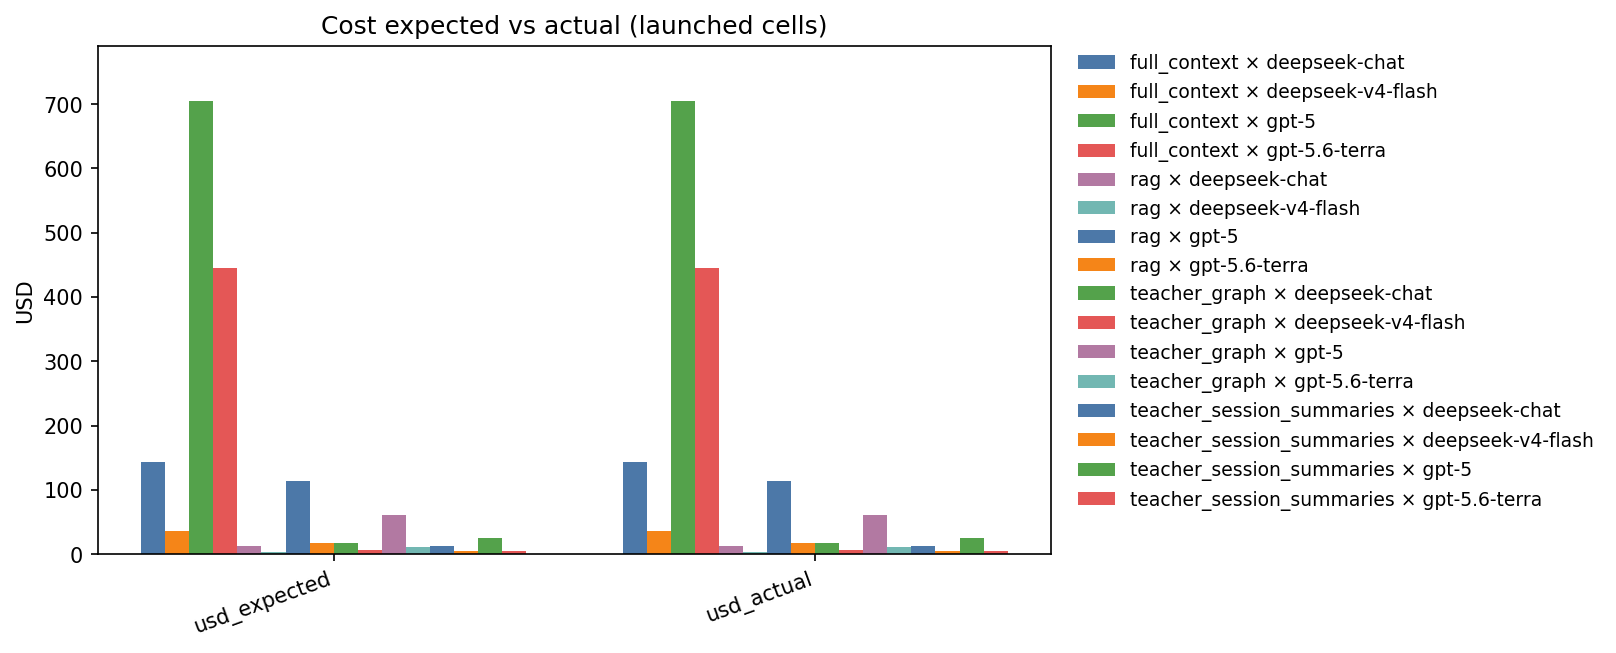

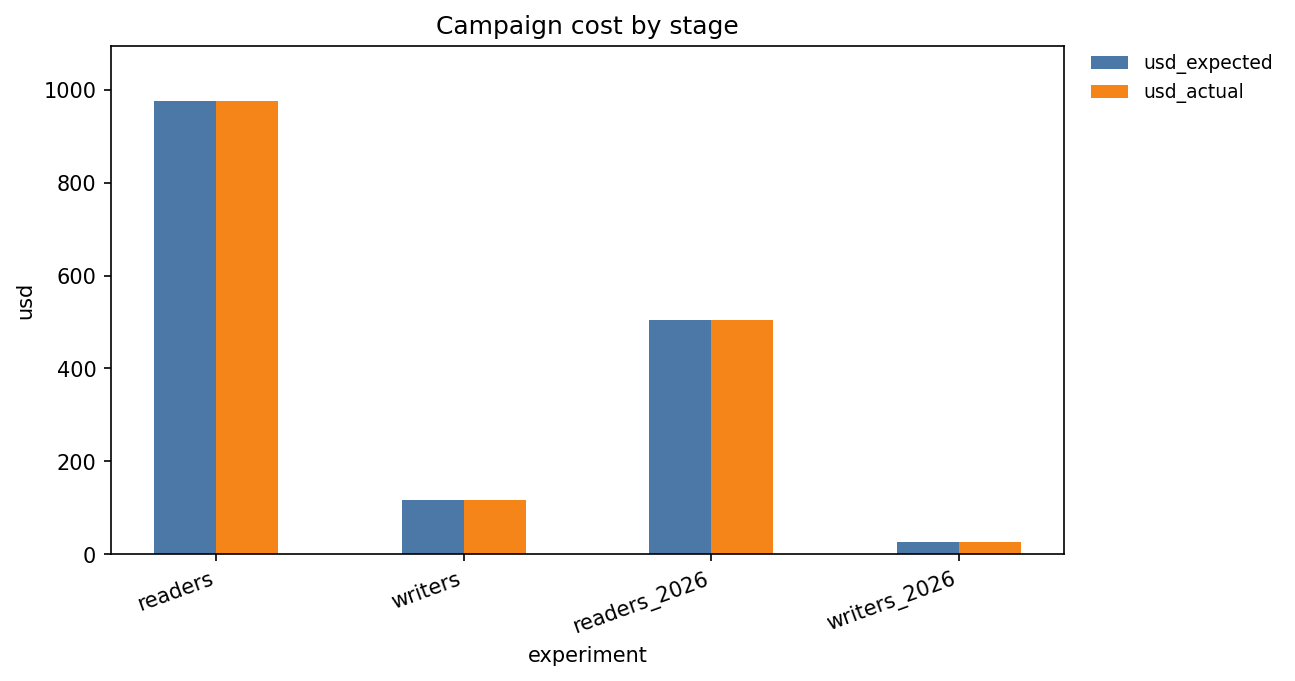

,check,result,detail
0,readers.n_cells,PASS,"expected 8, actual 8"
1,readers.n_questions,PASS,"expected 1986, actual 1986"
2,readers.usd,PASS,"expected $976.08, actual $976.08 (band 0.5–2.0×)"
3,writers.n_cells,PASS,"expected 8, actual 8"
4,writers.n_questions,PASS,"expected 1986, actual 1986"
5,writers.usd,PASS,"expected $116.11, actual $116.11 (band 0.5–2.0×)"
6,readers_2026.n_cells,PASS,"expected 8, actual 8"
7,readers_2026.n_questions,PASS,"expected 1986, actual 1986"
8,readers_2026.usd,PASS,"expected $504.06, actual $504.06 (band 0.5–2.0×)"
9,writers_2026.n_cells,PASS,"expected 8, actual 8"


In [4]:
report = render_campaign(camp, root=ROOT)
post = notebook_posttest(camp, report=report, root=ROOT)
post


## Future validation + research directions

Use the insight labels above as the evidence. Directions that stay in-scope for this repo:

1. **Freeze the reader only if `reader_rank_flips` is empty** on FC vs RAG across 2025/2026 and both families. A flip means the next sandwich YAML still needs a reader-sweep caveat.
2. **Pool teachers only if `writer_rank_flips` is empty** (or the flip is confined to thinking-on, which you would then pin off). Otherwise `pooled_teacher_graph` / `fused_teacher_graph` mix two teacher orderings.
3. **Gaps closing** on the writer axis are the case for multi-teacher: families become substitutes, fusion is about coverage not a stronger single teacher.
4. **Gaps widening** are the case for *keeping* heterogeneous teachers and studying fusion, not averaging them.
5. **Persistent holes** (especially LoCoMo multi-hop and temporal, category ids 1 and 2) are the claim-level / fusion research target. Do not “fix” them by swapping the frozen gpt-4o-mini reader — that confounds the middle layer.
6. **Thinking_flat or thinking_hurts** on writers: keep the matched on/off axis in the next campaign; do not silently default teachers to on.
7. **What is not moving** (`not_moving` on live 2025→2026) is as important as gains: that is the remaining task headroom after a year of frontier models.
8. **ROI:** prefer the family × method × thinking cell with higher `judge_score_per_usd` (and per second) unless a rank flip forbids freezing that axis. Thinking-on that is `thinking_flat` on J but slower/costlier is negative ROI.
9. **Saturation:** `near_ceiling` + `saturated_flat` means LoCoMo J is no longer a useful reader differentiator — move the scientific claim to holes, writers, or a harder memory condition. `diminishing_returns` is spend up, score stuck.
10. Out of scope here: Claude Fable (parked cost-only), claiming Mem0 paper Table 1–2 J from OSS clones, mixing a reader-prompt swap into a graph/store claim.

Re-run this notebook after the 2026 QA retry lands `_SUCCESS` and autorater/aggregate finish. Incomplete 2026 packs show as missing, not as zeros.
